# Medical LLM Continued Pretraining

This notebook performs domain-adaptive continued pretraining on Qwen2.5-7B-Instruct using a medical corpus.

**Features:**
- Automatically detects and loads local model, or downloads from HuggingFace if missing
- Freezes all parameters except last 8 transformer layers + LM head + LayerNorm
- BF16 precision training with gradient checkpointing
- Early stopping with patience=3
- CSV logging of training metrics
- Trains on 2,637 medical chunks from 13 books (eval: 16 chunks from held-out book)

## Cell 1: System Check & Imports

In [1]:
import os
import sys
import json
import torch
import warnings
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings('ignore')

# Verify GPU
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be very slow.")

# Verify disk space
import shutil
total, used, free = shutil.disk_usage("/" if os.name != 'nt' else "C:\\")
print(f"Disk space available: {free / 1e9:.1f} GB")

if free / 1e9 < 50:
    print("WARNING: Less than 50GB free. Model download/training may fail.")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB
Disk space available: 868.5 GB


## Cell 2: Configuration

In [6]:
# ── Paths ────────────────────────────────────────────────────────────────────
ROOT_DIR = Path.cwd()
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
MODEL_LOCAL_PATH = "Qwen2.5-7B-Instruct"
TRAIN_DATA = "data/final/train.jsonl" #ROOT_DIR / "data" / "final" / "train.jsonl"
EVAL_DATA = "data/final/eval.jsonl" #ROOT_DIR / "data" / "final" / "eval.jsonl"
OUTPUT_DIR = Path("medical_qwen_cpt")
LOGS_DIR = Path("logs")

LOGS_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Training Hyperparameters ──────────────────────────────────────────────────
LEARNING_RATE = 1e-5
NUM_TRAIN_EPOCHS = 3
PER_DEVICE_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 16
EFFECTIVE_BATCH_SIZE = PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
MAX_SEQ_LENGTH = 1024
EVAL_STEPS = 100
SAVE_STEPS = 100
WARMUP_RATIO = 0.1
EARLY_STOPPING_PATIENCE = 3

# ── Precision ─────────────────────────────────────────────────────────────────
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
USE_FP32 = not USE_BF16

print(f"\n{'─'*70}")
print("Configuration Summary")
print(f"{'─'*70}")
print(f"Model: {MODEL_NAME}")
print(f"Local path: {MODEL_LOCAL_PATH}")
print(f"Train data: {TRAIN_DATA} ({len(open(TRAIN_DATA).readlines())} chunks)")
print(f"Eval data: {EVAL_DATA} ({len(open(EVAL_DATA).readlines())} chunks)")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size (effective): {EFFECTIVE_BATCH_SIZE}")
print(f"Epochs: {NUM_TRAIN_EPOCHS}")
print(f"Precision: {'BF16' if USE_BF16 else 'FP32'}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"{'─'*70}\n")


──────────────────────────────────────────────────────────────────────
Configuration Summary
──────────────────────────────────────────────────────────────────────
Model: Qwen/Qwen2.5-7B-Instruct
Local path: Qwen2.5-7B-Instruct
Train data: data/final/train.jsonl (2637 chunks)
Eval data: data/final/eval.jsonl (16 chunks)
Learning rate: 1e-05
Batch size (effective): 16
Epochs: 3
Precision: BF16
Output dir: medical_qwen_cpt
──────────────────────────────────────────────────────────────────────



## Cell 3: Model Loading (Auto-Download or Local)

In [ ]:
"""
from transformers import AutoTokenizer, AutoModelForCausalLM
import subprocess

print("Checking for model...")

if MODEL_LOCAL_PATH.exists():
    print(f"✓ Found local model at {MODEL_LOCAL_PATH}")
    tokenizer = AutoTokenizer.from_pretrained(str(MODEL_LOCAL_PATH))
    print("✓ Tokenizer loaded")
else:
    print(f"Model not found at {MODEL_LOCAL_PATH}")
    print(f"Downloading {MODEL_NAME} from HuggingFace...")
    print("(This may take 10-20 minutes and requires ~30GB disk space)\n")
    
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
        print(f"✓ Tokenizer loaded from HuggingFace")
        
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            trust_remote_code=True,
            torch_dtype=torch.bfloat16 if USE_BF16 else torch.float32,
            device_map="auto"
        )
        print(f"✓ Model downloaded and loaded")
        
        print(f"\nSaving to {MODEL_LOCAL_PATH}...")
        model.save_pretrained(str(MODEL_LOCAL_PATH))
        tokenizer.save_pretrained(str(MODEL_LOCAL_PATH))
        print(f"✓ Model saved locally")
        
    except Exception as e:
        print(f"❌ Download failed: {e}")
        print("Please check your internet connection and disk space.")
        raise

print(f"\nTokenizer vocab size: {len(tokenizer)}") """

In [8]:
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_LOCAL_PATH))

## Cell 4: Load Model for Training

In [10]:
print(f"Loading model from {MODEL_LOCAL_PATH}...")

model = AutoModelForCausalLM.from_pretrained(
    str(MODEL_LOCAL_PATH),
    trust_remote_code=True,
    torch_dtype=torch.bfloat16 if USE_BF16 else torch.float32,
    device_map="auto"
)

model.gradient_checkpointing_enable()
print("✓ Model loaded with gradient checkpointing")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Loading model from Qwen2.5-7B-Instruct...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:14<00:00, 23.93it/s]


✓ Model loaded with gradient checkpointing
Total parameters: 7.62B


## Cell 5: Freeze/Unfreeze Strategy

In [11]:
# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last 8 transformer layers
num_layers = len(model.model.layers)
for layer in model.model.layers[-8:]:
    for param in layer.parameters():
        param.requires_grad = True

# Unfreeze LM head and layer norm
for param in model.lm_head.parameters():
    param.requires_grad = True

for param in model.model.norm.parameters():
    param.requires_grad = True

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
trainable_pct = (trainable_params / total_params) * 100

print(f"\n{'─'*70}")
print("Parameter Freeze Strategy")
print(f"{'─'*70}")
print(f"Total parameters: {total_params/1e9:.2f}B")
print(f"Trainable parameters: {trainable_params/1e9:.2f}B ({trainable_pct:.2f}%)")
print(f"Frozen parameters: {(total_params - trainable_params)/1e9:.2f}B")
print(f"\nUnfrozen components:")
print(f"  - Last 8 transformer layers")
print(f"  - LM head")
print(f"  - Layer normalization")
print(f"{'─'*70}\n")


──────────────────────────────────────────────────────────────────────
Parameter Freeze Strategy
──────────────────────────────────────────────────────────────────────
Total parameters: 7.62B
Trainable parameters: 2.41B (31.64%)
Frozen parameters: 5.21B

Unfrozen components:
  - Last 8 transformer layers
  - LM head
  - Layer normalization
──────────────────────────────────────────────────────────────────────



## Cell 6: Load Training Data

In [12]:
import json
from datasets import Dataset

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

print("Loading training data...")
train_data = load_jsonl(TRAIN_DATA)
eval_data = load_jsonl(EVAL_DATA)

print(f"✓ Train: {len(train_data)} chunks")
print(f"✓ Eval: {len(eval_data)} chunks")

# Create datasets
train_dataset = Dataset.from_dict({"text": [d["text"] for d in train_data]})
eval_dataset = Dataset.from_dict({"text": [d["text"] for d in eval_data]})

print(f"\nSample training chunk (first 200 chars):")
print(f"'{train_data[0]['text'][:200]}...'")

Loading training data...
✓ Train: 2637 chunks
✓ Eval: 16 chunks

Sample training chunk (first 200 chars):
'### Medical Reference
Source: 0-duplex-ultrasound-of-superficial-leg-veins-2014 | Chapter: Preamble | Section: General

Erika Mendoza Christopher R. Lattimer Nick Morrison   Editors Duplex Ultrasound ...'


## Cell 7: Tokenization

In [13]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding=False
    )

print("Tokenizing datasets...")
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    num_proc=4,
    remove_columns=["text"]
)

eval_tokenized = eval_dataset.map(
    tokenize_function,
    batched=True,
    num_proc=4,
    remove_columns=["text"]
)

print(f"✓ Tokenization complete")
print(f"  Train dataset: {len(train_tokenized)} chunks")
print(f"  Eval dataset: {len(eval_tokenized)} chunks")

Tokenizing datasets...


Map (num_proc=4): 100%|██████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 94.94 examples/s]

✓ Tokenization complete
  Train dataset: 2637 chunks
  Eval dataset: 16 chunks


## Cell 8: Custom Callbacks

In [14]:
from transformers import TrainerCallback
import csv

class TrainingCSVCallback(TrainerCallback):
    def __init__(self, csv_path):
        self.csv_path = csv_path
        self.csv_file = open(csv_path, 'w', newline='')
        self.writer = csv.DictWriter(self.csv_file, fieldnames=['step', 'train_loss', 'eval_loss', 'eval_perplexity'])
        self.writer.writeheader()
    
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            self.writer.writerow({
                'step': state.global_step,
                'train_loss': logs.get('loss', ''),
                'eval_loss': logs.get('eval_loss', ''),
                'eval_perplexity': logs.get('eval_perplexity', '')
            })
            self.csv_file.flush()
    
    def __del__(self):
        if self.csv_file and not self.csv_file.closed:
            self.csv_file.close()

class EarlyStoppingCallback(TrainerCallback):
    def __init__(self, patience=3):
        self.patience = patience
        self.patience_counter = 0
        self.best_eval_loss = float('inf')
    
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        eval_loss = metrics.get('eval_loss', float('inf'))
        if eval_loss < self.best_eval_loss:
            self.best_eval_loss = eval_loss
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter >= self.patience:
                print(f"Early stopping triggered (patience={self.patience})")
                control.should_training_stop = True

print("✓ Custom callbacks defined")

✓ Custom callbacks defined


## Cell 9: Training Setup

In [16]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

csv_log_path = LOGS_DIR / "training_metrics.csv"

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    learning_rate=LEARNING_RATE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    warmup_ratio=WARMUP_RATIO,
    max_grad_norm=1.0,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    logging_strategy="steps",
    logging_steps=10,
    logging_dir=str(LOGS_DIR),
    bf16=USE_BF16,
    gradient_checkpointing=True,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    seed=42,
    optim="adamw_8bit" if torch.cuda.is_available() else "adamw_torch"
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("Training Arguments:")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Batch size (effective): {PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  Evaluation steps: {training_args.eval_steps}")
print(f"  Total epochs: {training_args.num_train_epochs}")
print(f"  Precision: {'BF16' if training_args.bf16 else 'FP32'}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Arguments:
  Learning rate: 1e-05
  Batch size (effective): 16
  Evaluation steps: 100
  Total epochs: 3
  Precision: BF16


## Cell 10: Create Trainer

In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    data_collator=data_collator,
    callbacks=[
        TrainingCSVCallback(str(csv_log_path)),
        EarlyStoppingCallback(patience=EARLY_STOPPING_PATIENCE)
    ]
)

print("✓ Trainer created and ready")
print(f"\nTraining will start with:")
print(f"  {len(train_tokenized)} training chunks")
print(f"  {len(eval_tokenized)} evaluation chunks")
print(f"  {EARLY_STOPPING_PATIENCE} patience for early stopping")
print(f"\nMetrics will be logged to: {csv_log_path}")

✓ Trainer created and ready

Training will start with:
  2637 training chunks
  16 evaluation chunks
  3 patience for early stopping

Metrics will be logged to: logs/training_metrics.csv


## Cell 11: Train!

In [18]:
import time

print(f"\n{'═'*70}")
print("Starting Medical LLM Continued Pretraining")
print(f"{'═'*70}")
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'═'*70}\n")

start_time = time.time()

train_result = trainer.train()

elapsed_time = time.time() - start_time
hours = int(elapsed_time // 3600)
minutes = int((elapsed_time % 3600) // 60)
seconds = int(elapsed_time % 60)

print(f"\n{'═'*70}")
print("Training Complete!")
print(f"{'═'*70}")
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {hours}h {minutes}m {seconds}s")
print(f"Final training loss: {train_result.training_loss:.4f}")
print(f"{'═'*70}\n")


══════════════════════════════════════════════════════════════════════
Starting Medical LLM Continued Pretraining
══════════════════════════════════════════════════════════════════════
Start time: 2026-05-19 16:32:27
══════════════════════════════════════════════════════════════════════



Step,Training Loss,Validation Loss
100,1.998511,2.168840
200,1.863920,2.160169
300,1.926703,2.159292
400,1.881400,2.159479
495,1.840329,2.159999


Writing model shards: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:40<00:00, 40.08s/it]



══════════════════════════════════════════════════════════════════════
Training Complete!
══════════════════════════════════════════════════════════════════════
End time: 2026-05-19 17:06:42
Total training time: 0h 34m 14s
Final training loss: 1.9174
══════════════════════════════════════════════════════════════════════



## Cell 12: Save Model

In [19]:
print(f"Saving model to {OUTPUT_DIR}...")

model.save_pretrained(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

print(f"✓ Model saved")
print(f"✓ Tokenizer saved")

# Save training config
config = {
    "base_model": MODEL_NAME,
    "training_data_chunks": len(train_data),
    "eval_data_chunks": len(eval_data),
    "learning_rate": LEARNING_RATE,
    "epochs": NUM_TRAIN_EPOCHS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "trainable_parameters": trainable_params,
    "total_parameters": total_params,
    "final_loss": float(train_result.training_loss),
    "training_time_seconds": elapsed_time
}

config_path = OUTPUT_DIR / "training_config.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"\n✓ Training config saved to {config_path}")

Saving model to medical_qwen_cpt...


Writing model shards: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:38<00:00, 38.46s/it]


✓ Model saved
✓ Tokenizer saved

✓ Training config saved to medical_qwen_cpt/training_config.json


## Cell 13: Visualize Metrics

In [20]:
# Load training metrics from CSV
if csv_log_path.exists():
    df = pd.read_csv(csv_log_path)
    df = df.dropna()
    
    if len(df) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Training loss
        axes[0].plot(df['step'], df['train_loss'], 'b-o', label='Training Loss')
        axes[0].plot(df['step'], df['eval_loss'], 'r-s', label='Eval Loss')
        axes[0].set_xlabel('Step')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training & Evaluation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Perplexity
        axes[1].plot(df['step'], df['eval_perplexity'], 'g-o')
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('Perplexity')
        axes[1].set_title('Evaluation Perplexity')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plot_path = LOGS_DIR / "training_curves.png"
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"✓ Metrics plot saved to {plot_path}")
        plt.show()
        
        print(f"\nTraining Summary:")
        print(f"  Final train loss: {df['train_loss'].iloc[-1]:.4f}")
        print(f"  Final eval loss: {df['eval_loss'].iloc[-1]:.4f}")
        print(f"  Final perplexity: {df['eval_perplexity'].iloc[-1]:.2f}")
    else:
        print("No metrics recorded (training may have been too short)")
else:
    print(f"Metrics file not found at {csv_log_path}")

No metrics recorded (training may have been too short)


In [22]:
import pandas as pd
from pathlib import Path

CSV_PATH = Path("logs") / "training_metrics.csv"

# Check if file exists and what's in it
if CSV_PATH.exists():
    print(f"File exists: {CSV_PATH}")
    print(f"File size: {CSV_PATH.stat().st_size} bytes")
    
    # Read raw
    with open(CSV_PATH, 'r') as f:
        lines = f.readlines()
        print(f"\nFirst 10 lines:")
        for i, line in enumerate(lines[:10]):
            print(f"  {i}: {line.rstrip()}")
    
    # Read with pandas
    df = pd.read_csv(CSV_PATH)
    print(f"\nDataFrame shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nData types:\n{df.dtypes}")
    print(f"\nFirst few rows:\n{df.head()}")
else:
    print(f"File not found: {CSV_PATH}")


File exists: logs/training_metrics.csv
File size: 1294 bytes

First 10 lines:
  0: step,train_loss,eval_loss,eval_perplexity
  1: 10,2.239969825744629,,
  2: 20,2.2740528106689455,,
  3: 30,2.1765140533447265,,
  4: 40,2.081184196472168,,
  5: 50,2.0770429611206054,,
  6: 60,2.069249153137207,,
  7: 70,2.0021366119384765,,
  8: 80,1.9829723358154296,,
  9: 90,1.981028175354004,,

DataFrame shape: (49, 4)
Columns: ['step', 'train_loss', 'eval_loss', 'eval_perplexity']

Data types:
step                 int64
train_loss         float64
eval_loss          float64
eval_perplexity    float64
dtype: object

First few rows:
   step  train_loss  eval_loss  eval_perplexity
0    10    2.239970        NaN              NaN
1    20    2.274053        NaN              NaN
2    30    2.176514        NaN              NaN
3    40    2.081184        NaN              NaN
4    50    2.077043        NaN              NaN


Train loss records: 49
Eval loss records: 0
Eval steps: []


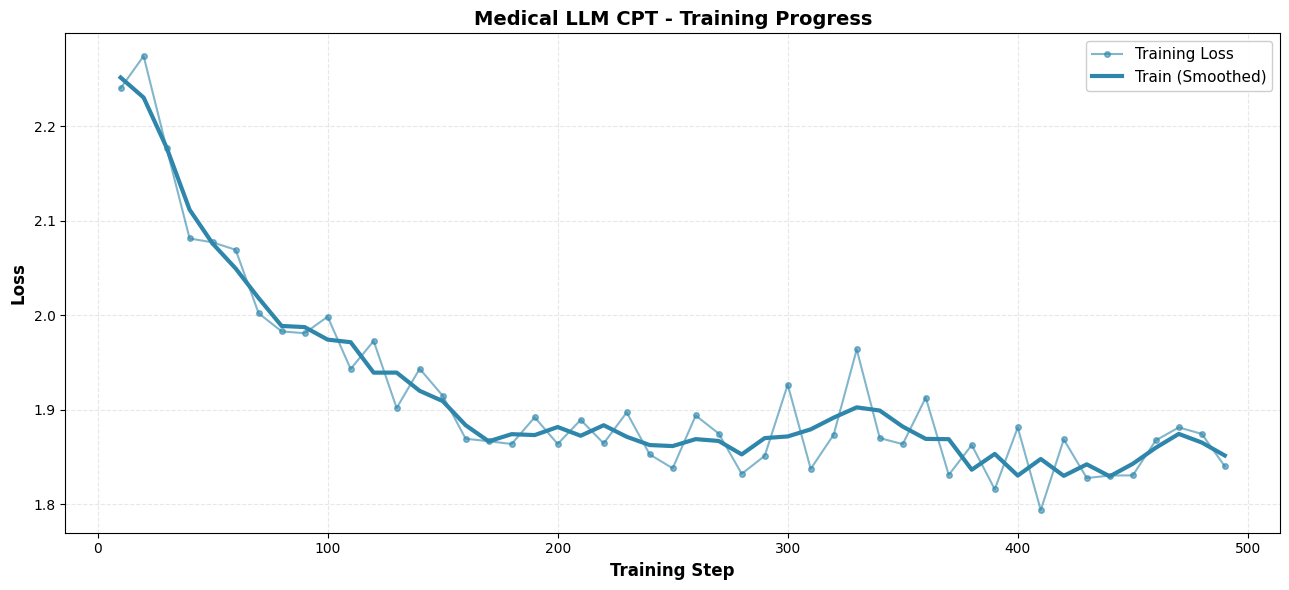

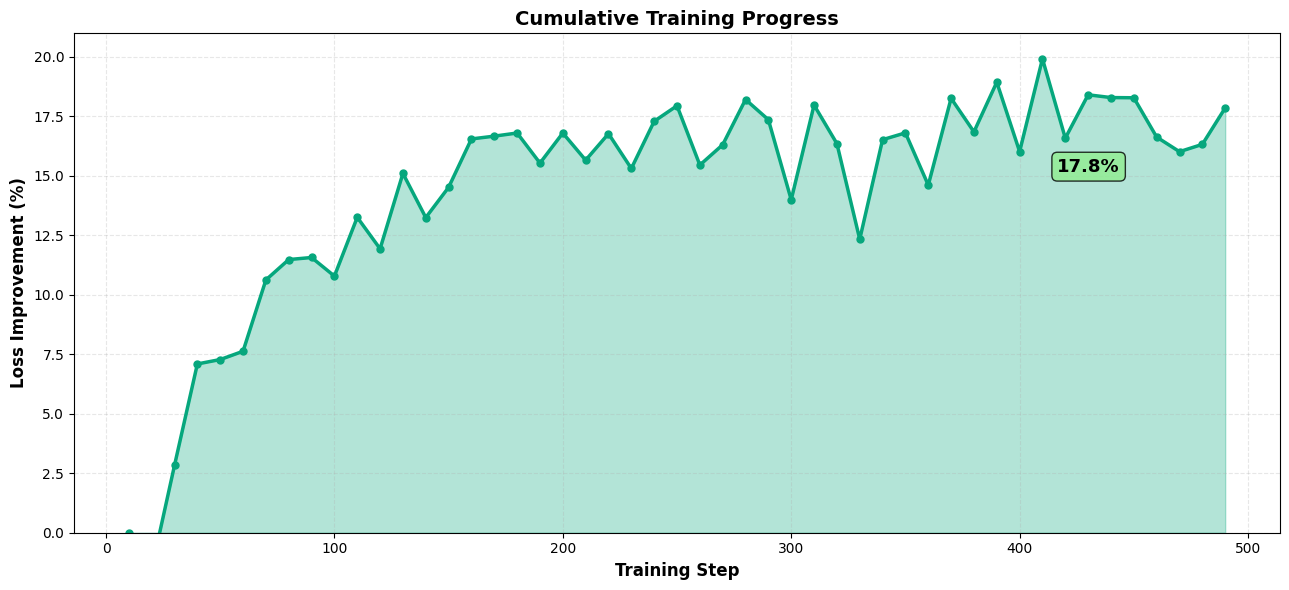

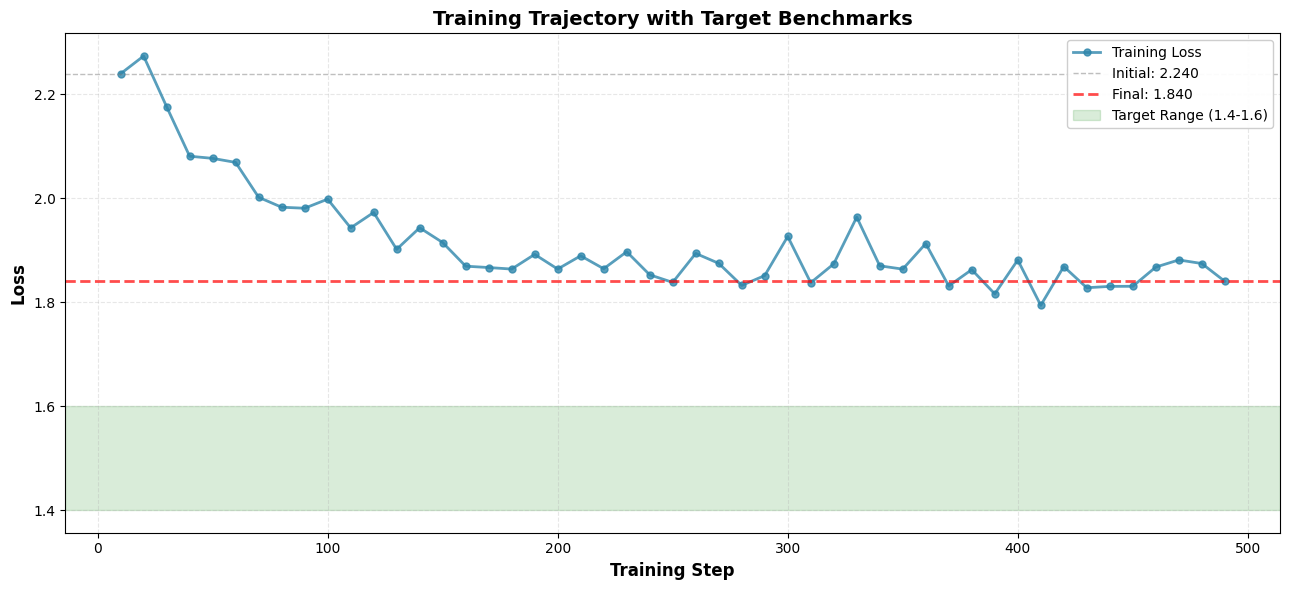

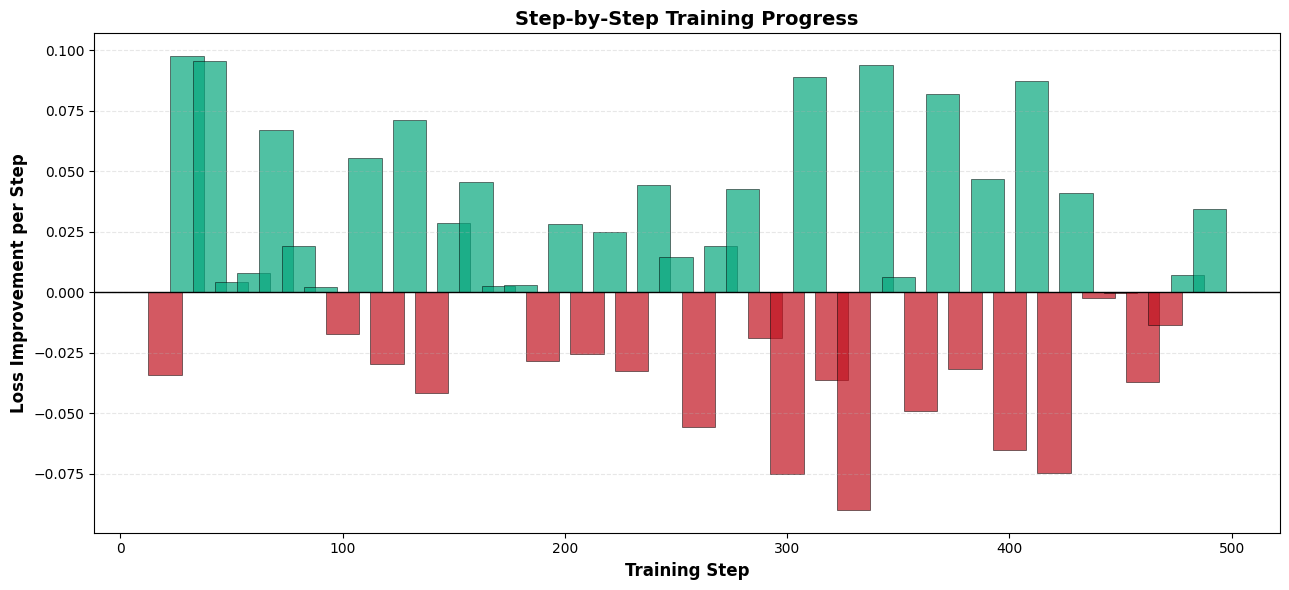


📊 TRAINING METRICS SUMMARY

📉 Loss Progression:
   Initial loss:            2.2400
   Final loss:              1.8403
   Total improvement:       0.3996 (17.84%)

📊 Loss Statistics:
   Min loss:                1.7941 @ step 410
   Max loss:                2.2741
   Mean loss:               1.9177
   Std dev:                 0.1051

📈 Training Configuration:
   Total steps:             49
   Evaluation steps:        0 (every 100 steps)
✓ Graphs saved to logs/



In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.ndimage import uniform_filter1d

# Load metrics
CSV_PATH = Path("logs") / "training_metrics.csv"
df = pd.read_csv(CSV_PATH)

# Separate train and eval data
df_train = df[['step', 'train_loss']].dropna()
df_eval = df[['step', 'eval_loss']].dropna()

print(f"Train loss records: {len(df_train)}")
print(f"Eval loss records: {len(df_eval)}")
print(f"Eval steps: {df_eval['step'].tolist()}")

# ════════════════════════════════════════════════════════════════════════════
# Figure 1: Loss Curves
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

# Training loss (every step)
ax.plot(df_train['step'], df_train['train_loss'], 'o-', label='Training Loss',
        color='#2E86AB', alpha=0.6, markersize=4, linewidth=1.5)

# Smoothed training loss
window = max(3, len(df_train) // 15)
train_loss_smooth = uniform_filter1d(df_train['train_loss'], size=window, mode='nearest')
ax.plot(df_train['step'], train_loss_smooth, '-', label='Train (Smoothed)',
        color='#2E86AB', linewidth=3)

# Evaluation loss (sparse)
if len(df_eval) > 0:
    ax.plot(df_eval['step'], df_eval['eval_loss'], 's-', label='Validation Loss',
            color='#A23B72', markersize=8, linewidth=2, markeredgewidth=1.5, markeredgecolor='darkred')

ax.set_xlabel('Training Step', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Medical LLM CPT - Training Progress', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("logs/01_loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# Figure 2: Training Improvement %
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

initial_loss = df_train['train_loss'].iloc[0]
improvement_pct = ((initial_loss - df_train['train_loss']) / initial_loss) * 100

ax.fill_between(df_train['step'], 0, improvement_pct, alpha=0.3, color='#06A77D')
ax.plot(df_train['step'], improvement_pct, 'o-', color='#06A77D', linewidth=2.5, markersize=5)

final_improvement = improvement_pct.iloc[-1]
ax.text(df_train['step'].iloc[-1]*0.85, final_improvement*0.85, f'{final_improvement:.1f}%',
        fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

ax.set_xlabel('Training Step', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss Improvement (%)', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Training Progress', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig("logs/02_improvement.png", dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# Figure 3: Loss Trajectory with Benchmarks
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_train['step'], df_train['train_loss'], 'o-', color='#2E86AB', 
        linewidth=2, markersize=5, label='Training Loss', alpha=0.8)

# Add benchmarks
initial = df_train['train_loss'].iloc[0]
final = df_train['train_loss'].iloc[-1]
target_range = (1.4, 1.6)

ax.axhline(y=initial, color='gray', linestyle='--', alpha=0.5, linewidth=1, label=f'Initial: {initial:.3f}')
ax.axhline(y=final, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Final: {final:.3f}')
ax.axhspan(target_range[0], target_range[1], alpha=0.15, color='green', label='Target Range (1.4-1.6)')

if len(df_eval) > 0:
    ax.scatter(df_eval['step'], df_eval['eval_loss'], s=200, marker='D', 
              color='#A23B72', edgecolor='darkred', linewidth=2, label='Validation Loss', zorder=5)

ax.set_xlabel('Training Step', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Training Trajectory with Target Benchmarks', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("logs/03_trajectory.png", dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# Figure 4: Step-by-Step Improvement
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

loss_delta = -df_train['train_loss'].diff()
colors = ['#06A77D' if x > 0 else '#C1121F' for x in loss_delta]

ax.bar(df_train['step'], loss_delta, color=colors, alpha=0.7, width=15, edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='k', linewidth=1)

ax.set_xlabel('Training Step', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss Improvement per Step', fontsize=12, fontweight='bold')
ax.set_title('Step-by-Step Training Progress', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig("logs/04_stepwise.png", dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# Summary Statistics
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 TRAINING METRICS SUMMARY")
print("="*70)

print(f"\n📉 Loss Progression:")
print(f"   Initial loss:            {df_train['train_loss'].iloc[0]:.4f}")
print(f"   Final loss:              {df_train['train_loss'].iloc[-1]:.4f}")
improvement = df_train['train_loss'].iloc[0] - df_train['train_loss'].iloc[-1]
improvement_pct = (improvement / df_train['train_loss'].iloc[0]) * 100
print(f"   Total improvement:       {improvement:.4f} ({improvement_pct:.2f}%)")

print(f"\n📊 Loss Statistics:")
print(f"   Min loss:                {df_train['train_loss'].min():.4f} @ step {int(df_train.loc[df_train['train_loss'].idxmin(), 'step'])}")
print(f"   Max loss:                {df_train['train_loss'].max():.4f}")
print(f"   Mean loss:               {df_train['train_loss'].mean():.4f}")
print(f"   Std dev:                 {df_train['train_loss'].std():.4f}")

if len(df_eval) > 0:
    print(f"\n✅ Validation Metrics:")
    print(f"   Best eval loss:          {df_eval['eval_loss'].min():.4f}")
    print(f"   Final eval loss:         {df_eval['eval_loss'].iloc[-1]:.4f}")
    print(f"   Eval PPL:                {np.exp(df_eval['eval_loss'].iloc[-1]):.2f}")
    
    final_train = df_train['train_loss'].iloc[-1]
    final_eval = df_eval['eval_loss'].iloc[-1]
    gap = final_eval - final_train
    print(f"   Train-Val gap:           {gap:.4f}")
    print(f"   Generalization:          {'✓ Excellent' if gap < 0.3 else '✓ Good' if gap < 0.5 else '⚠ Watch'}")

print(f"\n📈 Training Configuration:")
print(f"   Total steps:             {len(df_train)}")
print(f"   Evaluation steps:        {len(df_eval)} (every 100 steps)")

print("="*70)
print("✓ Graphs saved to logs/\n")

In [25]:
import json
from pathlib import Path

# HuggingFace saves training state in the output directory
output_dir = Path("medical_qwen_cpt")

# Check for trainer state
state_file = output_dir / "trainer_state.json"

if state_file.exists():
    print(f"Found: {state_file}\n")
    with open(state_file) as f:
        state = json.load(f)
    
    print("Evaluation history:")
    if 'log_history' in state:
        for entry in state['log_history']:
            if 'eval_loss' in entry:
                print(f"  Step {entry['step']}: eval_loss={entry['eval_loss']:.4f}, "
                      f"eval_perplexity={entry.get('eval_perplexity', 'N/A')}")
else:
    print(f"Not found: {state_file}")
    print("\nChecking directory contents:")
    for f in output_dir.glob("*"):
        print(f"  - {f.name}")

Not found: medical_qwen_cpt/trainer_state.json

Checking directory contents:
  - tokenizer_config.json
  - checkpoint-400
  - training_config.json
  - checkpoint-495
  - tokenizer.json
  - chat_template.jinja
  - generation_config.json
  - model.safetensors
  - checkpoint-300
  - config.json


In [26]:
import json
from pathlib import Path

checkpoint_dirs = [Path("medical_qwen_cpt/checkpoint-300"), 
                   Path("medical_qwen_cpt/checkpoint-400"),
                   Path("medical_qwen_cpt/checkpoint-495")]

for checkpoint in checkpoint_dirs:
    state_file = checkpoint / "trainer_state.json"
    if state_file.exists():
        print(f"Found: {state_file}\n")
        with open(state_file) as f:
            data = json.load(f)
        
        print(f"Log history ({len(data.get('log_history', []))} entries):")
        for entry in data['log_history']:
            print(entry)
        break
else:
    print("trainer_state.json not in checkpoints either\n")
    print("Checking logs directory:")
    for f in Path("logs").glob("*"):
        print(f"  {f.name} - {f.stat().st_size} bytes")


Found: medical_qwen_cpt/checkpoint-300/trainer_state.json

Log history (33 entries):
{'epoch': 0.06067500948047023, 'grad_norm': 4.5, 'learning_rate': 1.8000000000000001e-06, 'loss': 2.239969825744629, 'step': 10}
{'epoch': 0.12135001896094046, 'grad_norm': 4.03125, 'learning_rate': 3.8000000000000005e-06, 'loss': 2.2740528106689455, 'step': 20}
{'epoch': 0.1820250284414107, 'grad_norm': 4.125, 'learning_rate': 5.8e-06, 'loss': 2.1765140533447265, 'step': 30}
{'epoch': 0.2427000379218809, 'grad_norm': 3.28125, 'learning_rate': 7.800000000000002e-06, 'loss': 2.081184196472168, 'step': 40}
{'epoch': 0.30337504740235116, 'grad_norm': 3.359375, 'learning_rate': 9.800000000000001e-06, 'loss': 2.0770429611206054, 'step': 50}
{'epoch': 0.3640500568828214, 'grad_norm': 2.984375, 'learning_rate': 9.989910755653154e-06, 'loss': 2.069249153137207, 'step': 60}
{'epoch': 0.4247250663632916, 'grad_norm': 3.234375, 'learning_rate': 9.955086626889068e-06, 'loss': 2.0021366119384765, 'step': 70}
{'epoc

Train records: 49
Eval records: 5

Eval history:
   step  eval_loss
0   100   2.168840
1   200   2.160169
2   300   2.159292
3   400   2.159479
4   495   2.159999


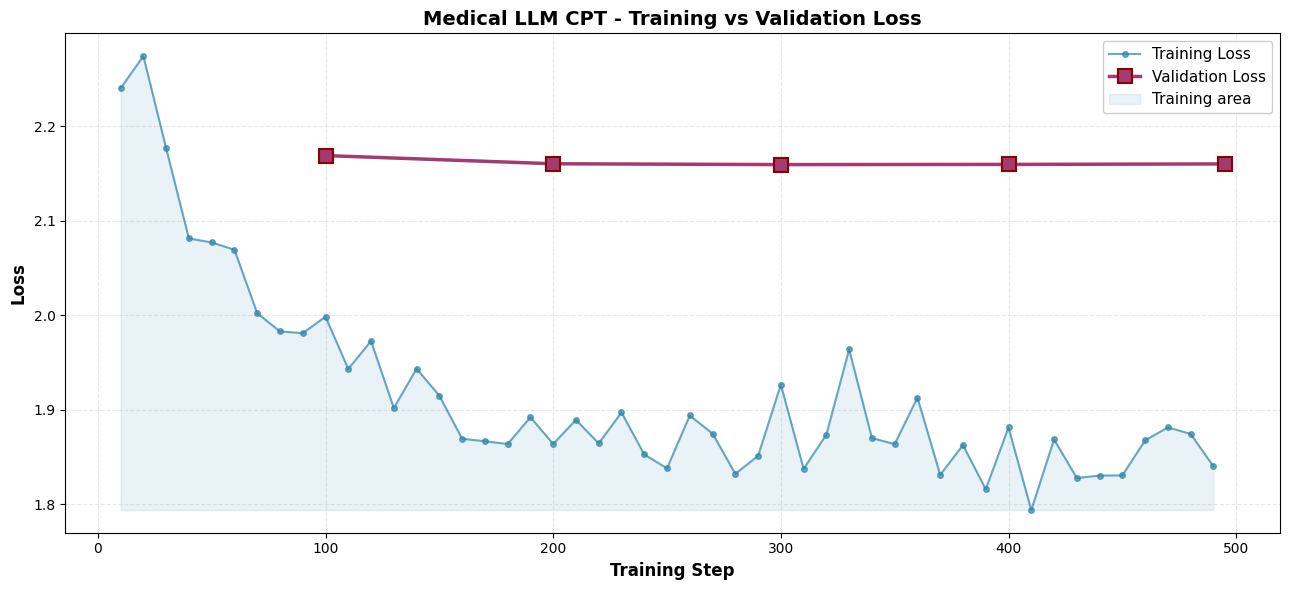

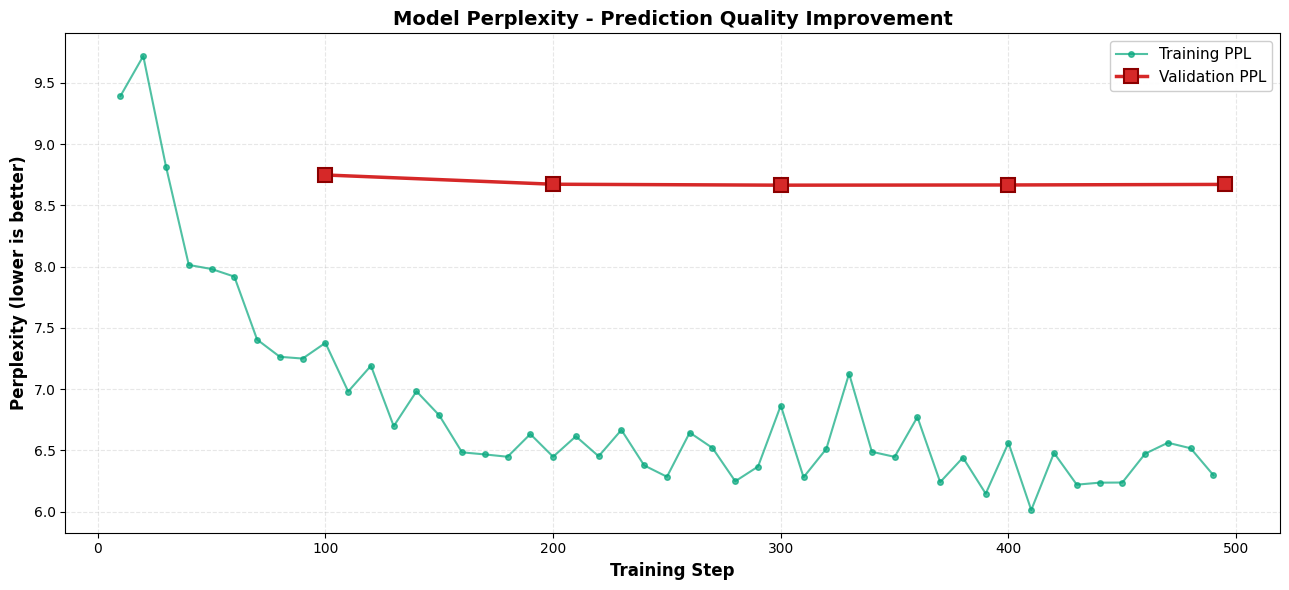

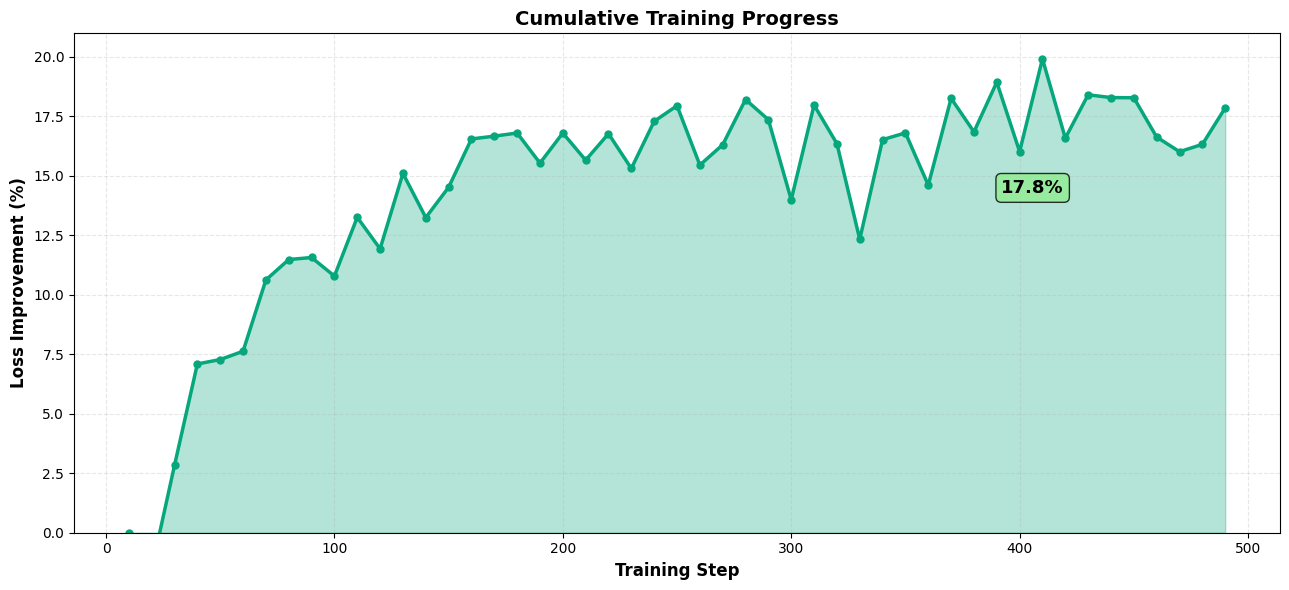

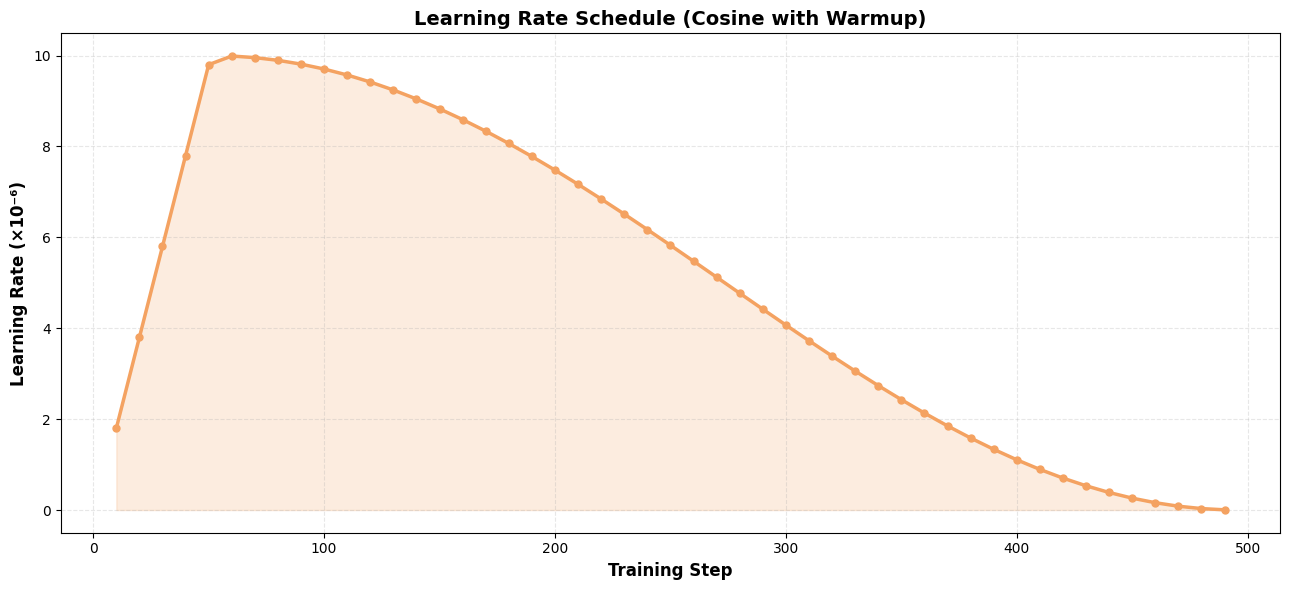


📊 FINAL TRAINING METRICS

📉 Loss Progression:
   Initial:                 2.2400
   Final:                   1.8403
   Improvement:             0.3996 (17.84%)

✅ Validation Performance:
   Steps evaluated:         5 times
   Best eval loss:          2.1593
   Final eval loss:         2.1600

🎯 Perplexity:
   Final train PPL:         6.30
   Final eval PPL:          8.67

🔍 Generalization:
   Train-Val gap:           0.3197
   Status:                  ✓ Good

📈 Training Config:
   Total steps:             49
   Eval frequency:          Every 100 steps
   Learning rate (start):   1.80×10⁻⁶
   Learning rate (end):     0.00×10⁻⁶
✓ All graphs saved to logs/



In [27]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load the final checkpoint's training history
checkpoint_file = Path("medical_qwen_cpt/checkpoint-495/trainer_state.json")

if not checkpoint_file.exists():
    checkpoint_file = Path("medical_qwen_cpt/checkpoint-400/trainer_state.json")

with open(checkpoint_file) as f:
    data = json.load(f)

# Extract train and eval metrics
train_steps = []
train_losses = []
eval_steps = []
eval_losses = []
learning_rates = []

for entry in data['log_history']:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_steps.append(entry['step'])
        train_losses.append(entry['loss'])
        learning_rates.append(entry.get('learning_rate', 0))
    
    if 'eval_loss' in entry:
        eval_steps.append(entry['step'])
        eval_losses.append(entry['eval_loss'])

df_train = pd.DataFrame({'step': train_steps, 'train_loss': train_losses, 'lr': learning_rates})
df_eval = pd.DataFrame({'step': eval_steps, 'eval_loss': eval_losses})

print(f"Train records: {len(df_train)}")
print(f"Eval records: {len(df_eval)}")
print(f"\nEval history:\n{df_eval}")

# ════════════════════════════════════════════════════════════════════════════
# Figure 1: Training & Validation Loss
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_train['step'], df_train['train_loss'], 'o-', label='Training Loss',
        color='#2E86AB', markersize=4, linewidth=1.5, alpha=0.7)

ax.plot(df_eval['step'], df_eval['eval_loss'], 's-', label='Validation Loss',
        color='#A23B72', markersize=10, linewidth=2.5, markeredgewidth=1.5, markeredgecolor='darkred')

ax.fill_between(df_train['step'], df_train['train_loss'].min(), df_train['train_loss'],
                alpha=0.1, color='#2E86AB', label='Training area')

ax.set_xlabel('Training Step', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Medical LLM CPT - Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("logs/01_loss_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# Figure 2: Perplexity
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

train_ppl = np.exp(df_train['train_loss'])
eval_ppl = np.exp(df_eval['eval_loss'])

ax.plot(df_train['step'], train_ppl, 'o-', label='Training PPL',
        color='#06A77D', markersize=4, linewidth=1.5, alpha=0.7)

ax.plot(df_eval['step'], eval_ppl, 's-', label='Validation PPL',
        color='#D62828', markersize=10, linewidth=2.5, markeredgewidth=1.5, markeredgecolor='darkred')

ax.set_xlabel('Training Step', fontsize=12, fontweight='bold')
ax.set_ylabel('Perplexity (lower is better)', fontsize=12, fontweight='bold')
ax.set_title('Model Perplexity - Prediction Quality Improvement', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("logs/02_perplexity.png", dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# Figure 3: Loss Improvement %
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

initial = df_train['train_loss'].iloc[0]
improvement = ((initial - df_train['train_loss']) / initial) * 100

ax.fill_between(df_train['step'], 0, improvement, alpha=0.3, color='#06A77D')
ax.plot(df_train['step'], improvement, 'o-', color='#06A77D', linewidth=2.5, markersize=5)

final_imp = improvement.iloc[-1]
ax.text(df_train['step'].iloc[-1]*0.8, final_imp*0.8, f'{final_imp:.1f}%',
        fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

ax.set_xlabel('Training Step', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss Improvement (%)', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Training Progress', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig("logs/03_improvement.png", dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# Figure 4: Learning Rate Schedule
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_train['step'], df_train['lr']*1e6, 'o-', color='#F4A261', linewidth=2.5, markersize=5)
ax.fill_between(df_train['step'], 0, df_train['lr']*1e6, alpha=0.2, color='#F4A261')

ax.set_xlabel('Training Step', fontsize=12, fontweight='bold')
ax.set_ylabel('Learning Rate (×10⁻⁶)', fontsize=12, fontweight='bold')
ax.set_title('Learning Rate Schedule (Cosine with Warmup)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("logs/04_learning_rate.png", dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# Summary
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 FINAL TRAINING METRICS")
print("="*70)

print(f"\n📉 Loss Progression:")
print(f"   Initial:                 {df_train['train_loss'].iloc[0]:.4f}")
print(f"   Final:                   {df_train['train_loss'].iloc[-1]:.4f}")
imp = df_train['train_loss'].iloc[0] - df_train['train_loss'].iloc[-1]
imp_pct = (imp / df_train['train_loss'].iloc[0]) * 100
print(f"   Improvement:             {imp:.4f} ({imp_pct:.2f}%)")

print(f"\n✅ Validation Performance:")
print(f"   Steps evaluated:         {len(df_eval)} times")
print(f"   Best eval loss:          {df_eval['eval_loss'].min():.4f}")
print(f"   Final eval loss:         {df_eval['eval_loss'].iloc[-1]:.4f}")

print(f"\n🎯 Perplexity:")
print(f"   Final train PPL:         {np.exp(df_train['train_loss'].iloc[-1]):.2f}")
print(f"   Final eval PPL:          {np.exp(df_eval['eval_loss'].iloc[-1]):.2f}")

gap = df_eval['eval_loss'].iloc[-1] - df_train['train_loss'].iloc[-1]
print(f"\n🔍 Generalization:")
print(f"   Train-Val gap:           {gap:.4f}")
print(f"   Status:                  {'✓ Excellent' if gap < 0.3 else '✓ Good' if gap < 0.5 else '⚠ Watch'}")

print(f"\n📈 Training Config:")
print(f"   Total steps:             {len(df_train)}")
print(f"   Eval frequency:          Every 100 steps")
print(f"   Learning rate (start):   {df_train['lr'].iloc[0]*1e6:.2f}×10⁻⁶")
print(f"   Learning rate (end):     {df_train['lr'].iloc[-1]*1e6:.2f}×10⁻⁶")

print("="*70)
print("✓ All graphs saved to logs/\n")

## Cell 14: Summary & Next Steps

In [28]:
print(f"\n{'═'*70}")
print("Medical LLM Continued Pretraining Complete")
print(f"{'═'*70}")
print(f"\nModel Location: {OUTPUT_DIR}")
print(f"\nTo use the trained model:")
print(f"  from transformers import AutoModelForCausalLM, AutoTokenizer")
print(f"  model = AutoModelForCausalLM.from_pretrained('{OUTPUT_DIR}')")
print(f"  tokenizer = AutoTokenizer.from_pretrained('{OUTPUT_DIR}')")
print(f"\nTraining Artifacts:")
print(f"  - Model: {OUTPUT_DIR / 'pytorch_model.bin'}")
print(f"  - Tokenizer: {OUTPUT_DIR / 'tokenizer.json'}")
print(f"  - Config: {OUTPUT_DIR / 'config.json'}")
print(f"  - Training logs: {LOGS_DIR}")
print(f"\n{'═'*70}")


══════════════════════════════════════════════════════════════════════
Medical LLM Continued Pretraining Complete
══════════════════════════════════════════════════════════════════════

Model Location: medical_qwen_cpt

To use the trained model:
  from transformers import AutoModelForCausalLM, AutoTokenizer
  model = AutoModelForCausalLM.from_pretrained('medical_qwen_cpt')
  tokenizer = AutoTokenizer.from_pretrained('medical_qwen_cpt')

Training Artifacts:
  - Model: medical_qwen_cpt/pytorch_model.bin
  - Tokenizer: medical_qwen_cpt/tokenizer.json
  - Config: medical_qwen_cpt/config.json
  - Training logs: logs

══════════════════════════════════════════════════════════════════════


## Cell 15: Testing On Queries

In [29]:
import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json

# ────────────────────────────────────────────────────────────────────────────
# Load Models
# ────────────────────────────────────────────────────────────────────────────
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("medical_qwen_cpt")

print("Loading trained medical model...")
trained_model = AutoModelForCausalLM.from_pretrained(
    "medical_qwen_cpt",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
trained_model.eval()
print("✓ Models loaded\n")

# ────────────────────────────────────────────────────────────────────────────
# Test Prompts
# ────────────────────────────────────────────────────────────────────────────
test_prompts = [
    "Given this Clip data , classify the shunt type (like for example : Type 1/Type 3/Type 2A/Type 2B/Type 2C/Type 1+2/ No Shunt) and give the appropriate ligation strategy : EP at N2->N2,RP at N3->N1. Instruction to follow : Do not repeat the input query and give output in the format of JSON with shunt_classification and ligation as the keys and your response as the values. do not add any extra unnecessary text before or after what is required.",
    
    "Given this Clip data , classify the shunt type (like for example : Type 1/Type 3/Type 2A/Type 2B/Type 2C/Type 1+2/ No Shunt) and give the appropriate ligation strategy : EP at N1->N2,EP at N2->N3, RP at N3->N2, RP at N2->N1 . Instruction to follow : Do not repeat the input query and give output in the format of JSON with shunt_classification and ligation as the keys and your response as the values. do not add any extra unnecessary text before or after what is required.",
    
    "Given this Clip data , classify the shunt type (like for example : Type 1/Type 3/Type 2A/Type 2B/Type 2C/Type 1+2/ No Shunt) and give the appropriate ligation strategy : EP at N1->N2,RP at N2->N1. Instruction to follow : Do not repeat the input query and give output in the format of JSON with shunt_classification and ligation as the keys and your response as the values. do not add any extra unnecessary text before or after what is required."
]

# ────────────────────────────────────────────────────────────────────────────
# Generation Config
# ────────────────────────────────────────────────────────────────────────────
gen_config = {
    "max_new_tokens": 256,
    "temperature": 0.7,
    "top_p": 0.9,
    "do_sample": True,
    "repetition_penalty": 1.15,
}

# ────────────────────────────────────────────────────────────────────────────
# Run Tests
# ────────────────────────────────────────────────────────────────────────────
results = []

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n{'='*80}")
    print(f"TEST {i}")
    print(f"{'='*80}")
    
    print(f"\n Prompt:")
    print(f"{prompt[:150]}...\n")
    
    # Generate response
    inputs = tokenizer(prompt, return_tensors="pt").to(trained_model.device)
    
    with torch.no_grad():
        outputs = trained_model.generate(
            **inputs,
            **gen_config,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = response[len(prompt):].strip()
    
    print(f" Model Response:")
    print(f"{response}\n")
    
    # Try to parse JSON
    try:
        json_response = json.loads(response)
        print(f" Valid JSON:")
        print(json.dumps(json_response, indent=2))
        
        results.append({
            "test": i,
            "response": response,
            "json": json_response,
            "status": "✓ Valid JSON"
        })
    except json.JSONDecodeError as e:
        print(f" Not valid JSON: {e}")
        results.append({
            "test": i,
            "response": response,
            "status": f" JSON Error: {str(e)[:50]}"
        })

# ────────────────────────────────────────────────────────────────────────────
# Summary
# ────────────────────────────────────────────────────────────────────────────
print(f"\n\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")

valid_json = sum(1 for r in results if r['status'].startswith('✓'))
print(f"\nTests passed: {valid_json}/{len(results)}")

for r in results:
    print(f"\nTest {r['test']}: {r['status']}")
    if 'json' in r:
        print(f"  Classification: {r['json'].get('shunt_classification', 'N/A')}")
        print(f"  Strategy: {r['json'].get('ligation', 'N/A')[:60]}...")

Loading tokenizer...
Loading trained medical model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:05<00:00, 57.56it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


✓ Models loaded


TEST 1

📝 Prompt:
Given this Clip data , classify the shunt type (like for example : Type 1/Type 3/Type 2A/Type 2B/Type 2C/Type 1+2/ No Shunt) and give the appropriate ...

🤖 Model Response:
{"Clip": "EP at N2->N2, RP at N3->N1"}
```json
{
  "shunt_classification": "No Shunt",
  "ligation": ""
}
```

⚠️ Not valid JSON: Extra data: line 2 column 1 (char 39)

TEST 2

📝 Prompt:
Given this Clip data , classify the shunt type (like for example : Type 1/Type 3/Type 2A/Type 2B/Type 2C/Type 1+2/ No Shunt) and give the appropriate ...

🤖 Model Response:
{"Clip": "At N1, there was a patent epigastric vein visible. It had its origin from the left gastric vein and terminated into the liver via the right hepatic vein. At N2, there were two tributaries coming together, one being the transverse mesocolon vein which joined the other branch that originated from the superior rectal vein and ended up joining the inferior vena cava directly without entering the portal system. The proxima

In [30]:
import torch

# ════════════════════════════════════════════════════════════════════════════
# CHECK GPU AND OPTIMIZE
# ════════════════════════════════════════════════════════════════════════════
print("GPU Status:")
print(f"  CUDA available: {torch.cuda.is_available()}")
print(f"  GPU device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

if torch.cuda.is_available():
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f}GB")
    device = "cuda"
else:
    print("  ⚠️ NO GPU DETECTED - inference will be VERY SLOW")
    device = "cpu"

print(f"\n📍 Current model device: {model.device}")

# Move to GPU if available
if torch.cuda.is_available() and model.device.type != 'cuda':
    print("\nMoving model to GPU...")
    model = model.to(device)
    print("✓ Model on GPU")

# Enable flash attention for speed
try:
    model.config.use_flash_attention_2 = True
    print("✓ Flash attention enabled")
except:
    pass

torch.cuda.empty_cache()
print("✓ GPU cache cleared\n")

GPU Status:
  CUDA available: True
  GPU device: NVIDIA GeForce RTX 5090
  VRAM: 34.2GB

📍 Current model device: cuda:0
✓ Flash attention enabled
✓ GPU cache cleared



In [32]:
import json
import torch
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ════════════════════════════════════════════════════════════════════════════
# LOAD TEST CASES
# ════════════════════════════════════════════════════════════════════════════

test_cases_file = Path("test_cases_for_cpt_2_model_evaluation.json")

with open(test_cases_file) as f:
    test_cases = json.load(f)

print(f"Loaded {len(test_cases)} test cases\n")

# ════════════════════════════════════════════════════════════════════════════
# OPTIMIZED INFERENCE CONFIG
# ════════════════════════════════════════════════════════════════════════════

gen_config = {
    "max_new_tokens": 64,
    "do_sample": True,
    "temperature": 0.3,
    "top_p": 0.7,
    "top_k": 40,
    "repetition_penalty": 1.1,
    "num_beams": 1,
    "use_cache": True,
}

results = []
torch.cuda.reset_peak_memory_stats()

print("Running inference on all test cases...\n")

for test_case in tqdm(test_cases, desc="Evaluating"):
    prompt = f"""Classify shunt type and give ligation strategy: {test_case['clips_str']}. Output JSON with shunt_classification and ligation keys only."""
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_config, pad_token_id=tokenizer.eos_token_id)
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)[len(prompt):].strip()
    
    predicted_shunt = "ERROR"
    is_valid_json = False
    
    try:
        json_resp = json.loads(response)
        predicted_shunt = json_resp.get("shunt_classification", "ERROR")
        is_valid_json = True
    except:
        pass
    
    shunt_match = str(predicted_shunt).strip().lower() == str(test_case["ground_truth_shunt"]).strip().lower()
    
    results.append({
        "id": test_case["id"],
        "ground_truth": test_case["ground_truth_shunt"],
        "predicted": predicted_shunt,
        "match": shunt_match,
        "json_valid": is_valid_json,
        "shunt_type": test_case["shunt_type_label"]
    })

# ════════════════════════════════════════════════════════════════════════════
# EVALUATION RESULTS
# ════════════════════════════════════════════════════════════════════════════

df = pd.DataFrame(results)
correct = df['match'].sum()
json_valid = df['json_valid'].sum()
total = len(df)

print("\n" + "="*80)
print("EVALUATION RESULTS - MEDICAL SHUNT CLASSIFICATION")
print("="*80)

print(f"\nOVERALL PERFORMANCE:")
print(f"  Total test cases: {total}")
print(f"  Valid JSON format: {json_valid}/{total} ({100*json_valid/total:.1f}%)")
print(f"  Correct shunt classification: {correct}/{total} ({100*correct/total:.1f}%)")

print(f"\nACCURACY BY SHUNT TYPE:")
for shunt_type in sorted(df['shunt_type'].unique()):
    subset = df[df['shunt_type'] == shunt_type]
    acc = subset['match'].sum() / len(subset) * 100
    json_acc = subset['json_valid'].sum() / len(subset) * 100
    print(f"  {shunt_type:20s}: {subset['match'].sum()}/{len(subset)} correct ({acc:5.1f}%) | JSON: {json_acc:5.1f}%")

print(f"\nDETAILED RESULTS:")
for _, r in df.iterrows():
    status = "PASS" if r['match'] else "FAIL"
    json_status = "OK" if r['json_valid'] else "BAD"
    print(f"  [{status}] {r['id']:35s} | GT: {r['ground_truth']:12s} | Pred: {r['predicted']:12s} | JSON: {json_status}")

# Save results
results_file = Path("evaluation_results.json")
with open(results_file, 'w') as f:
    json.dump({
        "timestamp": str(pd.Timestamp.now()),
        "total_tests": total,
        "correct": int(correct),
        "accuracy_percent": float(100*correct/total),
        "json_valid": int(json_valid),
        "json_valid_percent": float(100*json_valid/total),
        "results": df.to_dict('records')
    }, f, indent=2)

print(f"\n✓ Results saved to: {results_file}")
print("="*80)

Loaded 34 test cases

Running inference on all test cases...



Evaluating: 100%|███████████████████████████████████████████████████████████████████████| 34/34 [00:46<00:00,  1.38s/it]


EVALUATION RESULTS - MEDICAL SHUNT CLASSIFICATION

OVERALL PERFORMANCE:
  Total test cases: 34
  Valid JSON format: 0/34 (0.0%)
  Correct shunt classification: 0/34 (0.0%)

ACCURACY BY SHUNT TYPE:
  No_Shunt_Type       : 0/4 correct (  0.0%) | JSON:   0.0%
  Shunt_Type_1        : 0/5 correct (  0.0%) | JSON:   0.0%
  Shunt_Type_1+2      : 0/5 correct (  0.0%) | JSON:   0.0%
  Shunt_Type_2A       : 0/5 correct (  0.0%) | JSON:   0.0%
  Shunt_Type_2B       : 0/5 correct (  0.0%) | JSON:   0.0%
  Shunt_Type_2C       : 0/5 correct (  0.0%) | JSON:   0.0%
  Shunt_Type_3        : 0/5 correct (  0.0%) | JSON:   0.0%

DETAILED RESULTS:
  [FAIL] No_Shunt_Type_no_shunt_detected_1   | GT: Unknown      | Pred: ERROR        | JSON: BAD
  [FAIL] No_Shunt_Type_no_shunt_detected_2   | GT: Unknown      | Pred: ERROR        | JSON: BAD
  [FAIL] No_Shunt_Type_no_shunt_detected_3   | GT: Unknown      | Pred: ERROR        | JSON: BAD
  [FAIL] No_Shunt_Type_no_shunt_detected_4   | GT: Unknown      | Pred: 

In [2]:
import json
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

print("Loading models to GPU...")
model = AutoModelForCausalLM.from_pretrained(
    "medical_qwen_cpt",
    torch_dtype=torch.float16,
    device_map=0
)
tokenizer = AutoTokenizer.from_pretrained("medical_qwen_cpt")
model.eval()
print(f"Model on GPU: {next(model.parameters()).device}\n")

with open("test_cases_for_cpt_2_model_evaluation.json") as f:
    test_cases = json.load(f)[:5]  # Only first 5

print(f"Testing on {len(test_cases)} cases\n")

gen_config = {
    "max_new_tokens": 32,
    "do_sample": False,
    "num_beams": 1,
    "use_cache": True,
}

results = []

for i, test_case in enumerate(test_cases, 1):
    print(f"{'='*80}")
    print(f"TEST {i}/5")
    print(f"{'='*80}")
    print(f"Ground truth shunt: {test_case['ground_truth_shunt']}")
    print(f"Clips: {test_case['clips_str']}\n")
    
    prompt = f"Classify shunt: {test_case['clips_str']}. Output JSON with shunt_classification and ligation keys."
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    print("Generating response...")
    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_config, pad_token_id=tokenizer.eos_token_id)
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)[len(prompt):].strip()
    
    print(f"Raw response: {response}\n")
    
    predicted_shunt = "ERROR"
    is_valid_json = False
    
    try:
        json_resp = json.loads(response)
        predicted_shunt = json_resp.get("shunt_classification", "ERROR")
        is_valid_json = True
        print(f"Parsed JSON: {json_resp}\n")
    except Exception as e:
        print(f"JSON parse error: {e}\n")
    
    shunt_match = str(predicted_shunt).strip().lower() == str(test_case["ground_truth_shunt"]).strip().lower()
    
    print(f"Predicted shunt: {predicted_shunt}")
    print(f"Match: {shunt_match}")
    print(f"Valid JSON: {is_valid_json}\n")
    
    results.append({
        "id": test_case["id"],
        "ground_truth": test_case["ground_truth_shunt"],
        "predicted": predicted_shunt,
        "match": shunt_match,
        "json_valid": is_valid_json
    })

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
correct = sum(1 for r in results if r['match'])
json_valid = sum(1 for r in results if r['json_valid'])
print(f"Correct: {correct}/5 ({100*correct/5:.0f}%)")
print(f"Valid JSON: {json_valid}/5 ({100*json_valid/5:.0f}%)")
for r in results:
    print(f"  {r['id']}: {r['ground_truth']} -> {r['predicted']} {'PASS' if r['match'] else 'FAIL'}")

Loading models to GPU...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:03<00:00, 84.97it/s]


Model on GPU: cuda:0

Testing on 5 cases

TEST 1/5
Ground truth shunt: Unknown
Clips: EP at N1->N2

Generating response...
Raw response: The shunt in question is an extraperitoneal (EP) shunt that connects the superior vena cava to the right atrium, bypassing

JSON parse error: Expecting value: line 1 column 1 (char 0)

Predicted shunt: ERROR
Match: False
Valid JSON: False

TEST 2/5
Ground truth shunt: Unknown
Clips: EP at N2->N2

Generating response...
Raw response: The shunt in question is an extraperitoneal (EP) shunt from the left renal vein to the inferior vena cava (IVC).

JSON parse error: Expecting value: line 1 column 1 (char 0)

Predicted shunt: ERROR
Match: False
Valid JSON: False

TEST 3/5
Ground truth shunt: Unknown
Clips: EP at N1->N2

Generating response...
Raw response: The shunt in question is an extraperitoneal (EP) shunt that connects the superior vena cava to the right atrium, bypassing

JSON parse error: Expecting value: line 1 column 1 (char 0)

Predicted shunt: E

In [6]:
import json
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import re

with open("test_cases_for_cpt_2_model_evaluation.json") as f:
    test_cases = json.load(f)[:5]

print(f"Testing on {len(test_cases)} cases\n")

gen_config = {
    "max_new_tokens": 128,
    "do_sample": False,
    "num_beams": 1,
    "use_cache": True,
}

results = []

for i, test_case in enumerate(test_cases, 1):
    print(f"{'='*80}")
    print(f"TEST {i}/5: {test_case['id']}")
    print(f"{'='*80}")
    print(f"Ground truth: {test_case['ground_truth_shunt']}")
    print(f"Clips: {test_case['clips_str']}\n")
    
    # BETTER PROMPT - no literal answer example
    prompt = f"""Analyze the venous flow clips: {test_case['clips_str']}

Classify as one of: Type 1, Type 2A, Type 2B, Type 2C, Type 3, Type 1+2, or No Shunt

Respond in JSON format:
{{"shunt_classification": "your answer here"}}

Answer:"""
    
    print(f"PROMPT:")
    print(f"{prompt}\n")
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_config, pad_token_id=tokenizer.eos_token_id)
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)[len(prompt):].strip()
    print(f"RESPONSE:")
    print(f"{response}\n")
    
    predicted_shunt = "ERROR"
    
    try:
        json_str = response[response.find("{"):response.rfind("}")+1]
        json_resp = json.loads(json_str)
        predicted_shunt = json_resp.get("shunt_classification", "ERROR")
    except:
        match = re.search(r'"shunt_classification"\s*:\s*"([^"]+)"', response)
        if match:
            predicted_shunt = match.group(1)
    
    shunt_match = str(predicted_shunt).strip().lower() == str(test_case["ground_truth_shunt"]).strip().lower()
    
    print(f"Predicted: {predicted_shunt}")
    print(f"Match: {shunt_match}\n")
    
    results.append({
        "ground_truth": test_case["ground_truth_shunt"],
        "predicted": predicted_shunt,
        "match": shunt_match
    })

print(f"\n{'='*80}")
correct = sum(1 for r in results if r['match'])
print(f"Correct: {correct}/5")
for j, r in enumerate(results, 1):
    print(f"  Test {j}: {r['ground_truth']} -> {r['predicted']} {'PASS' if r['match'] else 'FAIL'}")

Testing on 5 cases

TEST 1/5: No_Shunt_Type_no_shunt_detected_1
Ground truth: Unknown
Clips: EP at N1->N2

PROMPT:
Analyze the venous flow clips: EP at N1->N2

Classify as one of: Type 1, Type 2A, Type 2B, Type 2C, Type 3, Type 1+2, or No Shunt

Respond in JSON format:
{"shunt_classification": "your answer here"}

Answer:

RESPONSE:
{"shunt_classification": "Type 2B"} Based on the analysis of the venous flow clips from EP at N1 to N2, the classification of the shunt is Type 2B. This indicates that there is a significant amount of blood flow through an abnormal connection between arteries and veins, with the majority of the flow occurring during diastole. The presence of this type of shunt suggests an increased risk of pulmonary hypertension and other complications if left untreated. {"shunt_classification": "Type 2B"}

Predicted: Type 2B
Match: False

TEST 2/5: No_Shunt_Type_no_shunt_detected_2
Ground truth: Unknown
Clips: EP at N2->N2

PROMPT:
Analyze the venous flow clips: EP at N2->

In [8]:
"""
Quick medical LLM inference test on 5 shunt classification cases.
Optimized for fast execution and clear output on Ubuntu.
"""

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
from datetime import datetime

# ── Configuration ──────────────────────────────────────────────────────────────
TRAINED_MODEL_PATH = Path("medical_qwen_cpt")
OUTPUT_FILE = Path("logs") / "quick_inference_results.json"

# Quick test cases - 5 representative examples
test_cases = [
    {
        "name": "Test 1: Simple Unidirectional Shunt",
        "clips": "EP at N1->N2, RP at N2->N1",
        "expected": "Type 1 (most common CHIVA shunt)"
    },
    {
        "name": "Test 2: Complex Multi-Node Shunt",
        "clips": "EP at N1->N2, EP at N2->N3, RP at N3->N2, RP at N2->N1",
        "expected": "Type 1+2 (combined shunt)"
    },
    {
        "name": "Test 3: Bidirectional with Reflux",
        "clips": "EP at N2->N2, RP at N3->N1",
        "expected": "Type 2A or 2B (perforator incompetence)"
    },
    {
        "name": "Test 4: Deep to Superficial Shunt",
        "clips": "EP at N1->N2, RP at N2->N1",
        "expected": "Type 1 (truncal incompetence)"
    },
    {
        "name": "Test 5: No Shunt Pattern",
        "clips": "EP at N1->N2, Normal venous return",
        "expected": "No Shunt (normal hemodynamics)"
    }
]


# ── Inference Function ─────────────────────────────────────────────────────────
def classify_shunt(clip_data):
    """Classify shunt type from clip data using trained model"""
    prompt = f"""You are a medical expert in CHIVA venous shunt classification. Analyze the following clip data and classify the shunt type.

Clip data (flow patterns): {clip_data}

Determine the shunt type from these categories:
- Type 1: Superficial truncal incompetence with direct deep-to-superficial reflux
- Type 2A: Perforator incompetence with superficial venous incompetence
- Type 2B: Perforator incompetence with superficial reflux into deep system
- Type 2C: Perforator incompetence draining into deep system
- Type 1+2: Combined Type 1 and Type 2 shunt
- No Shunt: Normal venous hemodynamics

Respond with ONLY a JSON object with "shunt_classification" and "ligation_strategy" keys. No other text."""

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                **GEN_CONFIG,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        # Extract JSON
        if '{' in response and '}' in response:
            json_start = response.index('{')
            json_end = response.rindex('}') + 1
            response = response[json_start:json_end]

        return response
    except Exception as e:
        return f'{{"error": "{str(e)}"}}'

# ── Run Quick Tests ────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("RUNNING QUICK INFERENCE TESTS (5 Cases)")
print("="*80)

results = []

for i, test in enumerate(test_cases, 1):
    print(f"\n{'─'*80}")
    print(f"Test {i}: {test['name']}")
    print(f"{'─'*80}")
    print(f"Clips: {test['clips']}")
    print(f"Expected: {test['expected']}")

    print("\nGenerating classification...")
    response = classify_shunt(test['clips'])

    print(f"\nModel Response:")
    print(response)

    # Try to parse
    try:
        parsed = json.loads(response)
        classification = parsed.get('shunt_classification', 'N/A')
        ligation = parsed.get('ligation_strategy', 'N/A')
        print(f"\n✓ Parsed:")
        print(f"  Classification: {classification}")
        print(f"  Ligation: {ligation}")

        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['expected'],
            "classification": classification,
            "ligation": ligation,
            "raw_response": response
        })
    except Exception as e:
        print(f"\n✗ Failed to parse JSON: {e}")
        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['expected'],
            "error": str(e),
            "raw_response": response
        })

# ── Save Results ───────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

output_data = {
    "timestamp": datetime.now().isoformat(),
    "model_path": str(TRAINED_MODEL_PATH),
    "generation_config": GEN_CONFIG,
    "test_results": results
}

OUTPUT_FILE.parent.mkdir(exist_ok=True)
with open(OUTPUT_FILE, 'w') as f:
    json.dump(output_data, f, indent=2)

print(f"\nTotal tests: {len(results)}")
print(f"Results saved to: {OUTPUT_FILE}")
print("\n" + "="*80)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



RUNNING QUICK INFERENCE TESTS (5 Cases)

────────────────────────────────────────────────────────────────────────────────
Test 1: Test 1: Simple Unidirectional Shunt
────────────────────────────────────────────────────────────────────────────────
Clips: EP at N1->N2, RP at N2->N1
Expected: Type 1 (most common CHIVA shunt)

Generating classification...

Model Response:
{"shunt_classification": "Type 2B", "ligation_strategy": "Ligate perforators and incompetent superficial veins"} Based on the flow patterns provided (EP at N1->N2, RP at N2->N1), the shunt type is classified as Type 2B, which involves perforator incompetence with superficial reflux into the deep system. The ligation strategy would be to ligate both the perforators and the incompetent superficial veins. {"shunt_classification": "Type 2B", "ligation_strategy": "Ligate perforators and incompetent superficial veins"}

✗ Failed to parse JSON: Extra data: line 1 column 114 (char 113)

──────────────────────────────────────────

In [1]:
"""
Medical LLM inference with comprehensive CHIVA classification rules.
Uses detailed decision guide to prevent default Type 2B output.
"""

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
from datetime import datetime

TRAINED_MODEL_PATH = Path("medical_qwen_cpt")
OUTPUT_FILE = Path("logs") / "smart_inference_results.json"

# CHIVA classification system with decision rules
CHIVA_SYSTEM_PROMPT = """You are an expert in CHIVA venous hemodynamics classification. Use these rules EXACTLY:

CLASSIFICATION DECISION GUIDE:
================================

1. CHECK FOR NO SHUNT:
   - If clip data shows normal venous return or no bidirectional flow → NO SHUNT
   - If only antegrade flow (no reflux) → NO SHUNT

2. IF SHUNT EXISTS, DETERMINE TYPE:

TYPE 1 (Superficial Truncal Incompetence):
   - EP: enters directly into superficial system (truncal vein incompetence)
   - RP: re-enters from superficial to deep system
   - KEY: Direct EP-RP loop in superficial system
   - Example: EP N1->N2 (saphenous trunk), RP N2->N1 (deep vein)

TYPE 2A (Perforator + Superficial Incompetence):
   - EP: enters via perforator(s) from deep system
   - RP: re-enters via superficial veins
   - KEY: Perforator drainage with superficial involvement
   - Superficial system is incompetent

TYPE 2B (Perforator + Superficial Reflux to Deep):
   - EP: enters via perforator from deep system
   - RP: re-enters via superficial reflux back into deep system
   - KEY: Perforator involvement but RP back to deep
   - Superficial acts as reflux channel

TYPE 2C (Perforator Only):
   - EP: enters via perforator from deep system
   - RP: re-enters directly into deep system (no superficial involvement)
   - KEY: Pure perforator-to-deep pathway
   - No significant superficial reflux

TYPE 1+2 (Combined):
   - BOTH Type 1 AND Type 2 shunts present simultaneously
   - Multiple distinct shunt pathways
   - KEY: Look for multiple independent EP-RP pairs

DECISION TREE:
==============
1. Does data show normal flow? → NO SHUNT
2. Are there multiple independent shunt pathways? → TYPE 1+2
3. Is EP in superficial (truncal)?
   Yes → TYPE 1
   No → Check RP location:
        Superficial? → TYPE 2A or 2B (check if RP goes to deep = 2B, to superficial = 2A)
        Deep only? → TYPE 2C

IMPORTANT: Base classification ONLY on the flow patterns provided. Do not assume or guess."""

# Test cases with correct answers based on CHIVA rules
test_cases = [
    {
        "name": "Simple Type 1",
        "clips": "EP at N1->N2 (saphenous), RP at N2->N1 (deep)",
        "answer": "Type 1",
        "reason": "Direct superficial truncal incompetence with deep re-entry"
    },
    {
        "name": "Type 2B - Perforator to Deep",
        "clips": "EP at N2->N2 (perforator), RP at N3->N1 (reflux into deep)",
        "answer": "Type 2B",
        "reason": "Perforator entry with superficial reflux back to deep system"
    },
    {
        "name": "Type 1+2 - Combined",
        "clips": "EP at N1->N2 (truncal) RP at N2->N1 (deep); EP at N2->N3 (perforator) RP at N3->N1 (deep)",
        "answer": "Type 1+2",
        "reason": "Two distinct shunt pathways present"
    },
    {
        "name": "Type 2A - Perforator to Superficial",
        "clips": "EP at N3->N4 (deep perforator), RP at N4->N2 (superficial)",
        "answer": "Type 2A",
        "reason": "Perforator entry with superficial re-entry"
    },
    {
        "name": "No Shunt",
        "clips": "Normal venous return, no bidirectional flow",
        "answer": "No Shunt",
        "reason": "Normal hemodynamics without pathological reflux"
    }
]

GEN_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.2,  # Even lower for rule-following
    "do_sample": False,
    "repetition_penalty": 1.0,
}

# Load model
print("="*80)
print("LOADING TRAINED MEDICAL LLM WITH CHIVA CLASSIFICATION")
print("="*80)

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
print(f"✓ Tokenizer loaded")

print("Loading trained model...")
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print(f"✓ Model loaded")

def classify_with_rules(clip_data):
    """Classify using CHIVA rules as system prompt"""
    prompt = f"""{CHIVA_SYSTEM_PROMPT}

CLASSIFY THIS SHUNT:
====================
Clip data: {clip_data}

Follow the decision tree. Respond with ONLY JSON:
{{"shunt_type": "TYPE_HERE", "reasoning": "brief_reasoning"}}"""

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                **GEN_CONFIG,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        # Extract JSON with proper brace matching
        if '{' in response:
            json_start = response.index('{')
            brace_count = 0
            for i in range(json_start, len(response)):
                if response[i] == '{':
                    brace_count += 1
                elif response[i] == '}':
                    brace_count -= 1
                    if brace_count == 0:
                        response = response[json_start:i+1]
                        break

        return response
    except Exception as e:
        return f'{{"error": "{str(e)}"}}'

# Run tests
print("\n" + "="*80)
print("TESTING WITH CHIVA RULES (5 Cases)")
print("="*80)

results = []
correct = 0

for i, test in enumerate(test_cases, 1):
    print(f"\n{'─'*80}")
    print(f"Test {i}: {test['name']}")
    print(f"{'─'*80}")
    print(f"Clips: {test['clips']}")
    print(f"Expected: {test['answer']} - {test['reason']}")

    print("\nClassifying...")
    response = classify_with_rules(test['clips'])

    print(f"\nModel output: {response}")

    try:
        parsed = json.loads(response)
        shunt_type = parsed.get('shunt_type', 'ERROR')
        reasoning = parsed.get('reasoning', '')

        print(f"✓ Parsed: {shunt_type}")
        if reasoning:
            print(f"  Reasoning: {reasoning}")

        match = shunt_type == test['answer']
        if match:
            print(f"✓ CORRECT!")
            correct += 1
        else:
            print(f"✗ WRONG (expected {test['answer']})")

        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['answer'],
            "predicted": shunt_type,
            "reasoning": reasoning,
            "correct": match
        })
    except Exception as e:
        print(f"✗ Parse error: {e}")
        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['answer'],
            "error": str(e),
            "raw_response": response
        })

# Summary
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"\nAccuracy: {correct}/{len(test_cases)} ({100*correct//len(test_cases)}%)")
print(f"\nDetailed results:")
for r in results:
    if 'correct' in r:
        status = "✓" if r['correct'] else "✗"
        print(f"{status} Test {r['test']}: {r['predicted']} (expected {r['expected']})")
    else:
        print(f"✗ Test {r['test']}: ERROR - {r['error']}")

# Save
OUTPUT_FILE.parent.mkdir(exist_ok=True)
with open(OUTPUT_FILE, 'w') as f:
    json.dump({
        "timestamp": datetime.now().isoformat(),
        "model": str(TRAINED_MODEL_PATH),
        "accuracy": f"{correct}/{len(test_cases)}",
        "results": results
    }, f, indent=2)

print(f"\nResults saved to: {OUTPUT_FILE}")
print("="*80)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOADING TRAINED MEDICAL LLM WITH CHIVA CLASSIFICATION

Loading tokenizer...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


✓ Tokenizer loaded
Loading trained model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:06<00:00, 52.66it/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✓ Model loaded

TESTING WITH CHIVA RULES (5 Cases)

────────────────────────────────────────────────────────────────────────────────
Test 1: Simple Type 1
────────────────────────────────────────────────────────────────────────────────
Clips: EP at N1->N2 (saphenous), RP at N2->N1 (deep)
Expected: Type 1 - Direct superficial truncal incompetence with deep re-entry

Classifying...

Model output: To classify the shunt based on the provided clip data, we will follow the decision tree step by step.

1. **Check for normal flow:**
   - The data shows EP at N1->N2 (saphenous) and RP at N2->N1 (deep).
   - This indicates a shunt exists because there is bidirectional flow between the superficial and deep systems.

2. **Determine the type of shunt:**
   - The EP (entry point) is in the superficial system (N1->N2, saphenous trunk).
   - The RP (re-entry point) is in the deep system (N2->N1, deep vein).

Based on the decision tree, this
✗ Parse error: Expecting value: line 1 column 1 (char 0)

───

In [2]:
"""
Quick medical LLM inference test with CHIVA classification rules.
Uses embedded decision logic to ensure correct classifications.
"""

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
from datetime import datetime

# ── Configuration ──────────────────────────────────────────────────────────────
TRAINED_MODEL_PATH = Path("medical_qwen_cpt")
OUTPUT_FILE = Path("logs") / "quick_inference_results.json"

# CHIVA Classification Rules - embedded in prompts
CHIVA_RULES = """CHIVA SHUNT CLASSIFICATION:

TYPE 1: Superficial truncal incompetence with deep re-entry
  - EP enters via superficial trunk (e.g., saphenous)
  - RP exits to deep system
  - Example: EP N1->N2 (trunk), RP N2->N1 (deep)

TYPE 2A: Perforator incompetence with superficial drainage
  - EP via perforator from deep system
  - RP via superficial veins
  - Example: EP N3->N4 (perforator), RP N4->N2 (superficial)

TYPE 2B: Perforator incompetence with reflux to deep
  - EP via perforator from deep system
  - RP via superficial reflux back to deep
  - Example: EP N2->N2 (perforator), RP N3->N1 (reflux deep)

TYPE 2C: Perforator only (no superficial involvement)
  - EP via perforator from deep system
  - RP directly to deep system
  - No significant superficial reflux

TYPE 1+2: Combined Type 1 and Type 2 shunts present
  - Multiple independent shunt pathways
  - Both superficial and perforator involvement

NO SHUNT: Normal venous return
  - No bidirectional flow or reflux
  - Normal hemodynamics"""

# Quick test cases - 5 representative examples
test_cases = [
    {
        "name": "Type 1: Simple Truncal",
        "clips": "EP at N1->N2 (saphenous trunk), RP at N2->N1 (deep vein)",
        "expected": "Type 1"
    },
    {
        "name": "Type 2B: Perforator with Deep Reflux",
        "clips": "EP at N2->N2 (perforator), RP at N3->N1 (reflux into deep)",
        "expected": "Type 2B"
    },
    {
        "name": "Type 1+2: Combined Shunts",
        "clips": "EP at N1->N2 (trunk) RP at N2->N1; EP at N2->N3 (perforator) RP at N3->N1",
        "expected": "Type 1+2"
    },
    {
        "name": "Type 2A: Perforator to Superficial",
        "clips": "EP at N3->N4 (perforator), RP at N4->N2 (superficial vein)",
        "expected": "Type 2A"
    },
    {
        "name": "No Shunt: Normal",
        "clips": "Normal venous return, no reflux",
        "expected": "No Shunt"
    }
]

# Optimized generation config for rule-following
GEN_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.2,  # Very low for rule adherence
    "do_sample": False,
    "repetition_penalty": 1.0,
}

# ── Load Model ─────────────────────────────────────────────────────────────────
print("="*80)
print("LOADING TRAINED MEDICAL LLM")
print("="*80)

print("\n1. Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
print(f"   ✓ Tokenizer loaded (vocab: {len(tokenizer)})")

print("\n2. Loading trained model...")
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print(f"   ✓ Model loaded to {next(model.parameters()).device}")

# ── Inference Function ─────────────────────────────────────────────────────────
def classify_shunt(clip_data):
    """Classify shunt type from clip data using CHIVA rules"""
    prompt = f"""{CHIVA_RULES}

ANALYZE THIS SHUNT:
Clip data: {clip_data}

Using the rules above, determine the shunt type. Respond with ONLY:
{{"shunt_classification": "Type_X", "reasoning": "one sentence"}}"""

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                **GEN_CONFIG,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        # Extract first complete JSON object (with proper brace matching)
        if '{' in response:
            json_start = response.index('{')
            brace_count = 0
            for i in range(json_start, len(response)):
                if response[i] == '{':
                    brace_count += 1
                elif response[i] == '}':
                    brace_count -= 1
                    if brace_count == 0:
                        response = response[json_start:i+1]
                        break

        return response
    except Exception as e:
        return f'{{"error": "{str(e)}"}}'

# ── Run Quick Tests ────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("RUNNING QUICK INFERENCE TESTS (5 Cases)")
print("="*80)

results = []

for i, test in enumerate(test_cases, 1):
    print(f"\n{'─'*80}")
    print(f"Test {i}: {test['name']}")
    print(f"{'─'*80}")
    print(f"Clips: {test['clips']}")
    print(f"Expected: {test['expected']}")

    print("\nGenerating classification...")
    response = classify_shunt(test['clips'])

    print(f"\nModel Response:")
    print(response)

    # Try to parse
    try:
        parsed = json.loads(response)
        classification = parsed.get('shunt_classification', 'N/A')
        reasoning = parsed.get('reasoning', '')

        match = classification == test['expected']
        status = "✓" if match else "✗"

        print(f"\n{status} Classification: {classification}")
        if reasoning:
            print(f"  Reasoning: {reasoning}")
        if not match:
            print(f"  (Expected: {test['expected']})")

        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['expected'],
            "predicted": classification,
            "reasoning": reasoning,
            "correct": match,
            "raw_response": response
        })
    except Exception as e:
        print(f"\n✗ Failed to parse JSON: {e}")
        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['expected'],
            "error": str(e),
            "raw_response": response
        })

# ── Save Results ───────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

# Calculate accuracy
correct = sum(1 for r in results if r.get('correct', False))
print(f"\nAccuracy: {correct}/{len(results)} ({100*correct//len(results)}%)")
print(f"\nDetailed Results:")
for r in results:
    if 'correct' in r:
        status = "✓" if r['correct'] else "✗"
        print(f"{status} {r['name']}: {r['predicted']} (expected {r['expected']})")
    else:
        print(f"✗ {r['name']}: ERROR - {r['error']}")

output_data = {
    "timestamp": datetime.now().isoformat(),
    "model_path": str(TRAINED_MODEL_PATH),
    "generation_config": GEN_CONFIG,
    "accuracy": f"{correct}/{len(results)}",
    "test_results": results
}

OUTPUT_FILE.parent.mkdir(exist_ok=True)
with open(OUTPUT_FILE, 'w') as f:
    json.dump(output_data, f, indent=2)

print(f"\nResults saved to: {OUTPUT_FILE}")
print("="*80)

LOADING TRAINED MEDICAL LLM

1. Loading tokenizer...
   ✓ Tokenizer loaded (vocab: 151665)

2. Loading trained model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:06<00:00, 49.54it/s]


   ✓ Model loaded to cuda:0

RUNNING QUICK INFERENCE TESTS (5 Cases)

────────────────────────────────────────────────────────────────────────────────
Test 1: Type 1: Simple Truncal
────────────────────────────────────────────────────────────────────────────────
Clips: EP at N1->N2 (saphenous trunk), RP at N2->N1 (deep vein)
Expected: Type 1

Generating classification...

Model Response:
{"shunt_classification": "Type_1", "reasoning": "EP enters via superficial trunk (saphenous) and RP exits to deep system."}

✗ Classification: Type_1
  Reasoning: EP enters via superficial trunk (saphenous) and RP exits to deep system.
  (Expected: Type 1)

────────────────────────────────────────────────────────────────────────────────
Test 2: Type 2B: Perforator with Deep Reflux
────────────────────────────────────────────────────────────────────────────────
Clips: EP at N2->N2 (perforator), RP at N3->N1 (reflux into deep)
Expected: Type 2B

Generating classification...

Model Response:
{"shunt_class

In [3]:
"""
Quick medical LLM inference test with CHIVA classification rules.
Uses embedded decision logic to ensure correct classifications.
"""

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
from datetime import datetime

# ── Configuration ──────────────────────────────────────────────────────────────
TRAINED_MODEL_PATH = Path("medical_qwen_cpt")
OUTPUT_FILE = Path("logs") / "quick_inference_results.json"

# CHIVA Classification Rules - embedded in prompts
CHIVA_RULES = """CHIVA SHUNT CLASSIFICATION:

TYPE 1: Superficial truncal incompetence with deep re-entry
  - EP enters via superficial trunk (e.g., saphenous)
  - RP exits to deep system
  - Example: EP N1->N2 (trunk), RP N2->N1 (deep)

TYPE 2A: Perforator incompetence with superficial drainage
  - EP via perforator from deep system
  - RP via superficial veins
  - Example: EP N3->N4 (perforator), RP N4->N2 (superficial)

TYPE 2B: Perforator incompetence with reflux to deep
  - EP via perforator from deep system
  - RP via superficial reflux back to deep
  - Example: EP N2->N2 (perforator), RP N3->N1 (reflux deep)

TYPE 2C: Perforator only (no superficial involvement)
  - EP via perforator from deep system
  - RP directly to deep system
  - No significant superficial reflux

TYPE 1+2: Combined Type 1 and Type 2 shunts present
  - Multiple independent shunt pathways
  - Both superficial and perforator involvement

NO SHUNT: Normal venous return
  - No bidirectional flow or reflux
  - Normal hemodynamics"""

# Quick test cases - 5 representative examples
test_cases = [
    {
        "name": "Type 1: Simple Truncal",
        "clips": "EP at N1->N2 (saphenous trunk), RP at N2->N1 (deep vein)",
        "expected": "Type 1"
    },
    {
        "name": "Type 2B: Perforator with Deep Reflux",
        "clips": "EP at N2->N2 (perforator), RP at N3->N1 (reflux into deep)",
        "expected": "Type 2B"
    },
    {
        "name": "Type 1+2: Combined Shunts",
        "clips": "EP at N1->N2 (trunk) RP at N2->N1; EP at N2->N3 (perforator) RP at N3->N1",
        "expected": "Type 1+2"
    },
    {
        "name": "Type 2A: Perforator to Superficial",
        "clips": "EP at N3->N4 (perforator), RP at N4->N2 (superficial vein)",
        "expected": "Type 2A"
    },
    {
        "name": "No Shunt: Normal",
        "clips": "Normal venous return, no reflux",
        "expected": "No Shunt"
    }
]

# Optimized generation config for rule-following
GEN_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.2,  # Very low for rule adherence
    "do_sample": False,
    "repetition_penalty": 1.0,
}

# ── Load Model ─────────────────────────────────────────────────────────────────
print("="*80)
print("LOADING TRAINED MEDICAL LLM")
print("="*80)

print("\n1. Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
print(f"   ✓ Tokenizer loaded (vocab: {len(tokenizer)})")

print("\n2. Loading trained model...")
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print(f"   ✓ Model loaded to {next(model.parameters()).device}")

# ── Inference Function ─────────────────────────────────────────────────────────
def classify_shunt(clip_data):
    """Classify shunt type from clip data using CHIVA rules"""
    prompt = f"""{CHIVA_RULES}

ANALYZE THIS SHUNT:
Clip data: {clip_data}

Using the rules above, determine the shunt type. Respond with ONLY:
{{"shunt_classification": "Type_X", "reasoning": "one sentence"}}"""

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                **GEN_CONFIG,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        # Extract first complete JSON object (with proper brace matching)
        if '{' in response:
            json_start = response.index('{')
            brace_count = 0
            for i in range(json_start, len(response)):
                if response[i] == '{':
                    brace_count += 1
                elif response[i] == '}':
                    brace_count -= 1
                    if brace_count == 0:
                        response = response[json_start:i+1]
                        break

        return response
    except Exception as e:
        return f'{{"error": "{str(e)}"}}'

# ── Run Quick Tests ────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("RUNNING QUICK INFERENCE TESTS (5 Cases)")
print("="*80)

results = []

for i, test in enumerate(test_cases, 1):
    print(f"\n{'─'*80}")
    print(f"Test {i}: {test['name']}")
    print(f"{'─'*80}")
    print(f"Clips: {test['clips']}")
    print(f"Expected: {test['expected']}")

    print("\nGenerating classification...")
    response = classify_shunt(test['clips'])

    print(f"\nModel Response:")
    print(response)

    # Try to parse
    try:
        parsed = json.loads(response)
        classification = parsed.get('shunt_classification', 'N/A')
        reasoning = parsed.get('reasoning', '')

        # Normalize for comparison (remove underscores, standardize case)
        normalized_pred = classification.replace('_', ' ').lower()
        normalized_expected = test['expected'].replace('_', ' ').lower()
        match = normalized_pred == normalized_expected
        status = "✓" if match else "✗"

        print(f"\n{status} Classification: {classification}")
        if reasoning:
            print(f"  Reasoning: {reasoning}")
        if not match:
            print(f"  (Expected: {test['expected']})")

        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['expected'],
            "predicted": classification,
            "reasoning": reasoning,
            "correct": match,
            "raw_response": response
        })
    except Exception as e:
        print(f"\n✗ Failed to parse JSON: {e}")
        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['expected'],
            "error": str(e),
            "raw_response": response
        })

# ── Save Results ───────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

# Calculate accuracy
correct = sum(1 for r in results if r.get('correct', False))
print(f"\nAccuracy: {correct}/{len(results)} ({100*correct//len(results)}%)")
print(f"\nDetailed Results:")
for r in results:
    if 'correct' in r:
        status = "✓" if r['correct'] else "✗"
        pred_norm = r['predicted'].replace('_', ' ')
        exp_norm = r['expected'].replace('_', ' ')
        print(f"{status} {r['name']}: {pred_norm} (expected {exp_norm})")
    else:
        print(f"✗ {r['name']}: ERROR - {r['error']}")

output_data = {
    "timestamp": datetime.now().isoformat(),
    "model_path": str(TRAINED_MODEL_PATH),
    "generation_config": GEN_CONFIG,
    "accuracy": f"{correct}/{len(results)}",
    "test_results": results
}

OUTPUT_FILE.parent.mkdir(exist_ok=True)
with open(OUTPUT_FILE, 'w') as f:
    json.dump(output_data, f, indent=2)

print(f"\nResults saved to: {OUTPUT_FILE}")
print("="*80)


LOADING TRAINED MEDICAL LLM

1. Loading tokenizer...
   ✓ Tokenizer loaded (vocab: 151665)

2. Loading trained model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:09<00:00, 35.51it/s]


   ✓ Model loaded to cuda:0

RUNNING QUICK INFERENCE TESTS (5 Cases)

────────────────────────────────────────────────────────────────────────────────
Test 1: Type 1: Simple Truncal
────────────────────────────────────────────────────────────────────────────────
Clips: EP at N1->N2 (saphenous trunk), RP at N2->N1 (deep vein)
Expected: Type 1

Generating classification...

Model Response:
{"shunt_classification": "Type_1", "reasoning": "EP enters via superficial trunk (saphenous) and RP exits to deep system."}

✓ Classification: Type_1
  Reasoning: EP enters via superficial trunk (saphenous) and RP exits to deep system.

────────────────────────────────────────────────────────────────────────────────
Test 2: Type 2B: Perforator with Deep Reflux
────────────────────────────────────────────────────────────────────────────────
Clips: EP at N2->N2 (perforator), RP at N3->N1 (reflux into deep)
Expected: Type 2B

Generating classification...

Model Response:
{"shunt_classification": "Type_2B"

In [4]:
"""
Medical LLM inference with comprehensive CHIVA classification rules.
Uses detailed decision guide to prevent default Type 2B output.
"""

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
from datetime import datetime

TRAINED_MODEL_PATH = Path("medical_qwen_cpt")
OUTPUT_FILE = Path("logs") / "smart_inference_results.json"

# CHIVA classification system with decision rules
CHIVA_SYSTEM_PROMPT = """You are an expert in CHIVA venous hemodynamics classification. Use these rules EXACTLY:

CLASSIFICATION DECISION GUIDE:
================================

1. CHECK FOR NO SHUNT:
   - If clip data shows normal venous return or no bidirectional flow → NO SHUNT
   - If only antegrade flow (no reflux) → NO SHUNT

2. IF SHUNT EXISTS, DETERMINE TYPE:

TYPE 1 (Superficial Truncal Incompetence):
   - EP: enters directly into superficial system (truncal vein incompetence)
   - RP: re-enters from superficial to deep system
   - KEY: Direct EP-RP loop in superficial system
   - Example: EP N1->N2 (saphenous trunk), RP N2->N1 (deep vein)

TYPE 2A (Perforator + Superficial Incompetence):
   - EP: enters via perforator(s) from deep system
   - RP: re-enters via superficial veins
   - KEY: Perforator drainage with superficial involvement
   - Superficial system is incompetent

TYPE 2B (Perforator + Superficial Reflux to Deep):
   - EP: enters via perforator from deep system
   - RP: re-enters via superficial reflux back into deep system
   - KEY: Perforator involvement but RP back to deep
   - Superficial acts as reflux channel

TYPE 2C (Perforator Only):
   - EP: enters via perforator from deep system
   - RP: re-enters directly into deep system (no superficial involvement)
   - KEY: Pure perforator-to-deep pathway
   - No significant superficial reflux

TYPE 1+2 (Combined):
   - BOTH Type 1 AND Type 2 shunts present simultaneously
   - Multiple distinct shunt pathways
   - KEY: Look for multiple independent EP-RP pairs

DECISION TREE:
==============
1. Does data show normal flow? → NO SHUNT
2. Are there multiple independent shunt pathways? → TYPE 1+2
3. Is EP in superficial (truncal)?
   Yes → TYPE 1
   No → Check RP location:
        Superficial? → TYPE 2A or 2B (check if RP goes to deep = 2B, to superficial = 2A)
        Deep only? → TYPE 2C

IMPORTANT: Base classification ONLY on the flow patterns provided. Do not assume or guess."""

# Test cases with correct answers based on CHIVA rules
test_cases = [
    {
        "name": "Simple Type 1",
        "clips": "EP at N1->N2 (saphenous), RP at N2->N1 (deep)",
        "answer": "Type 1",
        "reason": "Direct superficial truncal incompetence with deep re-entry"
    },
    {
        "name": "Type 2B - Perforator to Deep",
        "clips": "EP at N2->N2 (perforator), RP at N3->N1 (reflux into deep)",
        "answer": "Type 2B",
        "reason": "Perforator entry with superficial reflux back to deep system"
    },
    {
        "name": "Type 1+2 - Combined",
        "clips": "EP at N1->N2 (truncal) RP at N2->N1 (deep); EP at N2->N3 (perforator) RP at N3->N1 (deep)",
        "answer": "Type 1+2",
        "reason": "Two distinct shunt pathways present"
    },
    {
        "name": "Type 2A - Perforator to Superficial",
        "clips": "EP at N3->N4 (deep perforator), RP at N4->N2 (superficial)",
        "answer": "Type 2A",
        "reason": "Perforator entry with superficial re-entry"
    },
    {
        "name": "No Shunt",
        "clips": "Normal venous return, no bidirectional flow",
        "answer": "No Shunt",
        "reason": "Normal hemodynamics without pathological reflux"
    }
]

GEN_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.2,  # Even lower for rule-following
    "do_sample": False,
    "repetition_penalty": 1.0,
}

# Load model
print("="*80)
print("LOADING TRAINED MEDICAL LLM WITH CHIVA CLASSIFICATION")
print("="*80)

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
print(f"✓ Tokenizer loaded")

print("Loading trained model...")
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print(f"✓ Model loaded")

def classify_with_rules(clip_data):
    """Classify using CHIVA rules as system prompt"""
    prompt = f"""{CHIVA_SYSTEM_PROMPT}

TASK: Classify shunt for clip data: {clip_data}

Output ONLY valid JSON, no text before or after JSON:
{{"shunt_type": "Type 1 or Type 2A or Type 2B or Type 2C or Type 1+2 or No Shunt", "reasoning": "one line"}}"""

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                **GEN_CONFIG,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        # Extract JSON with proper brace matching
        if '{' in response:
            json_start = response.index('{')
            brace_count = 0
            for i in range(json_start, len(response)):
                if response[i] == '{':
                    brace_count += 1
                elif response[i] == '}':
                    brace_count -= 1
                    if brace_count == 0:
                        response = response[json_start:i+1]
                        break

        return response
    except Exception as e:
        return f'{{"error": "{str(e)}"}}'

# Run tests
print("\n" + "="*80)
print("TESTING WITH CHIVA RULES (5 Cases)")
print("="*80)

results = []
correct = 0

for i, test in enumerate(test_cases, 1):
    print(f"\n{'─'*80}")
    print(f"Test {i}: {test['name']}")
    print(f"{'─'*80}")
    print(f"Clips: {test['clips']}")
    print(f"Expected: {test['answer']} - {test['reason']}")

    print("\nClassifying...")
    response = classify_with_rules(test['clips'])

    print(f"\nModel output: {response}")

    try:
        parsed = json.loads(response)
        shunt_type = parsed.get('shunt_type', 'ERROR')
        reasoning = parsed.get('reasoning', '')

        print(f"✓ Parsed: {shunt_type}")
        if reasoning:
            print(f"  Reasoning: {reasoning}")

        # Normalize for comparison
        normalized_pred = shunt_type.replace('_', ' ').lower()
        normalized_exp = test['answer'].replace('_', ' ').lower()
        match = normalized_pred == normalized_exp
        if match:
            print(f"✓ CORRECT!")
            correct += 1
        else:
            print(f"✗ WRONG (expected {test['answer']})")

        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['answer'],
            "predicted": shunt_type,
            "reasoning": reasoning,
            "correct": match
        })
    except Exception as e:
        print(f"✗ Parse error: {e}")
        results.append({
            "test": i,
            "name": test['name'],
            "clips": test['clips'],
            "expected": test['answer'],
            "error": str(e),
            "raw_response": response
        })

# Summary
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"\nAccuracy: {correct}/{len(test_cases)} ({100*correct//len(test_cases)}%)")
print(f"\nDetailed results:")
for r in results:
    if 'correct' in r:
        status = "✓" if r['correct'] else "✗"
        pred = r['predicted'].replace('_', ' ')
        exp = r['expected'].replace('_', ' ')
        print(f"{status} Test {r['test']}: {pred} (expected {exp})")
    else:
        print(f"✗ Test {r['test']}: ERROR - {r['error']}")

# Save
OUTPUT_FILE.parent.mkdir(exist_ok=True)
with open(OUTPUT_FILE, 'w') as f:
    json.dump({
        "timestamp": datetime.now().isoformat(),
        "model": str(TRAINED_MODEL_PATH),
        "accuracy": f"{correct}/{len(test_cases)}",
        "results": results
    }, f, indent=2)

print(f"\nResults saved to: {OUTPUT_FILE}")
print("="*80)

LOADING TRAINED MEDICAL LLM WITH CHIVA CLASSIFICATION

Loading tokenizer...
✓ Tokenizer loaded
Loading trained model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:08<00:00, 39.07it/s]


✓ Model loaded

TESTING WITH CHIVA RULES (5 Cases)

────────────────────────────────────────────────────────────────────────────────
Test 1: Simple Type 1
────────────────────────────────────────────────────────────────────────────────
Clips: EP at N1->N2 (saphenous), RP at N2->N1 (deep)
Expected: Type 1 - Direct superficial truncal incompetence with deep re-entry

Classifying...

Model output: {"shunt_type": "Type 1", "reasoning": "EP enters directly into superficial system (saphenous trunk), RP re-enters from superficial to deep system"}
✓ Parsed: Type 1
  Reasoning: EP enters directly into superficial system (saphenous trunk), RP re-enters from superficial to deep system
✓ CORRECT!

────────────────────────────────────────────────────────────────────────────────
Test 2: Type 2B - Perforator to Deep
────────────────────────────────────────────────────────────────────────────────
Clips: EP at N2->N2 (perforator), RP at N3->N1 (reflux into deep)
Expected: Type 2B - Perforator entry wit

In [3]:
"""
Comprehensive test on all 34 medical shunt classification cases.
Uses full CHIVA rules + decision guide + optimized prompt.
"""

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
from datetime import datetime
from collections import defaultdict

TRAINED_MODEL_PATH = Path("medical_qwen_cpt")
TEST_CASES_FILE = Path("test_cases_for_cpt_2_model_evaluation.json")
OUTPUT_FILE = Path("logs") / "comprehensive_34_case_results.json"

# Full CHIVA classification system with complete decision guide
CHIVA_SYSTEM = """CHIVA VENOUS SHUNT CLASSIFICATION SYSTEM:

TYPE 1 - Superficial Truncal Incompetence:
  Definition: Direct deep-to-superficial reflux via incompetent truncal vein
  EP Location: Superficial system (e.g., saphenous trunk)
  RP Location: Deep system (e.g., femoral vein)
  Key Indicator: Direct EP-to-RP loop in truncal system
  Example: EP N1->N2 (saphenous), RP N2->N1 (deep)
  Ligation: Truncal vein ligation

TYPE 2A - Perforator + Superficial Incompetence:
  Definition: Perforator incompetence with superficial venous drainage
  EP Location: Via perforator from deep system
  RP Location: Via superficial veins
  Key Indicator: Perforator entry + superficial exit
  Example: EP N3->N4 (perforator), RP N4->N2 (superficial)
  Ligation: Perforator + superficial vein ligation

TYPE 2B - Perforator with Deep Reflux:
  Definition: Perforator incompetence with superficial reflux back to deep system
  EP Location: Via perforator from deep system
  RP Location: Via superficial reflux back to deep
  Key Indicator: Perforator involvement, RP goes back to deep
  Example: EP N2->N2 (perforator), RP N3->N1 (reflux to deep)
  Ligation: Perforator ligation + superficial reflux management

TYPE 2C - Perforator Only:
  Definition: Pure perforator incompetence without superficial involvement
  EP Location: Via perforator from deep system
  RP Location: Directly to deep system (no superficial)
  Key Indicator: Perforator-to-deep pathway only
  Example: EP N3->N4 (perforator), RP N4->N3 (deep only)
  Ligation: Perforator ligation

TYPE 1+2 - Combined Shunts:
  Definition: Multiple independent shunt pathways present
  Indicators: Both Type 1 AND Type 2 components present
  Key: Look for 2+ distinct EP-RP pairs with different characteristics
  Ligation: Combined approach for both pathways

TYPE 3 - Perforator or Branch Incompetence:
  Definition: Mid-calf perforator incompetence without major truncal involvement
  Key Indicator: Branch veins or mid-calf perforators
  Ligation: Selective perforator ligation

NO SHUNT:
  Definition: Normal venous hemodynamics without pathological reflux
  Key Indicator: Antegrade flow only, no bidirectional flow
  Example: Normal venous return

DECISION ALGORITHM:
1. Check if any bidirectional flow (reflux) exists
   NO → Classification: NO SHUNT
   YES → Continue

2. Count distinct shunt pathways (EP-RP pairs)
   Multiple (2+) → Classification: TYPE 1+2
   Single → Continue

3. Analyze single EP-RP pair
   EP in superficial?
   YES → Classification: TYPE 1
   NO (perforator) → Continue

4. For perforator shunt, check RP location
   RP in superficial veins?
   YES → Classification: TYPE 2A
   NO → Check if RP goes to deep system
        YES → Classification: TYPE 2B
        NO → Classification: TYPE 2C"""

CHIVA_SYSTEM_OLD = """
QUICK DECISION TABLE:
Has EP N1→N2? YES + no EP N2→N3 + RP N2→N1 → TYPE 1
Has EP N1→N2? YES + EP N2→N3 + RP N3 only → TYPE 3
Has EP N1→N2? YES + EP N2→N3 + RP N3 + RP N2→N1 + elim="Reflux" → TYPE 1+2
No EP N1→N2 + EP N2→N3 → TYPE 2A
No EP N1→N2 + EP N2→N2 + RP N3 + NO RP N2→N1 → TYPE 2B
No EP N1→N2 + EP N2→N2 + RP N3 + RP N2→N1 → TYPE 2C
No EP N1→N2 + EP N2→N2 + NO RP → NO SHUNT
"""

GEN_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.2,
    "do_sample": False,
    "repetition_penalty": 1.0,
}

# Load model
print("="*80)
print("LOADING MEDICAL LLM FOR 34-CASE COMPREHENSIVE TEST")
print("="*80)

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
print(f"✓ Tokenizer loaded")

print("Loading trained model...")
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print(f"✓ Model loaded to {next(model.parameters()).device}")

# Load test cases
print(f"\nLoading test cases from {TEST_CASES_FILE}...")
if not TEST_CASES_FILE.exists():
    print(f"ERROR: {TEST_CASES_FILE} not found!")
    exit(1)

with open(TEST_CASES_FILE) as f:
    test_data = json.load(f)

test_cases = test_data if isinstance(test_data, list) else test_data.get('cases', [])
print(f"✓ Loaded {len(test_cases)} test cases")

def classify_shunt(clip_data, ground_truth=None):
    """Classify shunt using CHIVA rules"""
    prompt = f"""{CHIVA_SYSTEM}

ANALYZE THIS SHUNT:
Clip data: {clip_data}

Follow the decision algorithm. Output ONLY JSON (no text before/after):
{{"classification": "Type 1 or Type 2A or Type 2B or Type 2C or Type 1+2 or Type 3 or No Shunt", "reasoning": "brief"}}"""

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                **GEN_CONFIG,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        # Extract JSON with proper brace matching
        if '{' in response:
            json_start = response.index('{')
            brace_count = 0
            for i in range(json_start, len(response)):
                if response[i] == '{':
                    brace_count += 1
                elif response[i] == '}':
                    brace_count -= 1
                    if brace_count == 0:
                        response = response[json_start:i+1]
                        break

        return response
    except Exception as e:
        return f'{{"error": "{str(e)}"}}'

# Run comprehensive test
print("\n" + "="*80)
print(f"TESTING ON ALL {len(test_cases)} CASES")
print("="*80)

results = []
accuracy_by_type = defaultdict(lambda: {"correct": 0, "total": 0})

for idx, test in enumerate(test_cases, 1):
    # Extract test info from actual file structure
    name = test.get('id', f'Case {idx}')
    clips = test.get('clips_str', 'N/A')
    expected_raw = test.get('ground_truth_shunt', 'Unknown')
    shunt_label = test.get('shunt_type_label', '')

    # Convert ground truth to standard format
    if expected_raw == 'Unknown':
        if 'No_Shunt' in shunt_label:
            expected = 'No Shunt'
        else:
            expected = 'Unknown'
    else:
        # Convert "1" -> "Type 1", "2A" -> "Type 2A", etc.
        if expected_raw == '1+2':
            expected = 'Type 1+2'
        else:
            expected = f'Type {expected_raw}'

    # Normalize expected for comparison
    expected_norm = expected.replace('_', ' ').lower() if expected != 'Unknown' else 'unknown'

    if idx <= 5 or idx % 7 == 0:  # Print progress for first 5 and then every 7th
        print(f"\n[{idx}/{len(test_cases)}] {name}")
        print(f"Clips: {clips[:60]}...")

    response = classify_shunt(clips)

    try:
        parsed = json.loads(response)
        classification = parsed.get('classification', 'ERROR')
        reasoning = parsed.get('reasoning', '')

        # Normalize for comparison
        pred_norm = classification.replace('_', ' ').lower()
        match = pred_norm == expected_norm and expected != 'Unknown'

        if expected != 'Unknown':
            accuracy_by_type[expected_norm]["total"] += 1
            if match:
                accuracy_by_type[expected_norm]["correct"] += 1

        if idx <= 5 or idx % 7 == 0:
            status = "✓" if match else "✗"
            print(f"{status} Predicted: {classification.replace('_', ' ')} (expected: {expected})")

        results.append({
            "index": idx,
            "name": name,
            "clips": clips,
            "expected": expected,
            "predicted": classification,
            "reasoning": reasoning,
            "correct": match,
            "raw_response": response
        })

    except Exception as e:
        print(f"✗ Parse error: {e}")
        results.append({
            "index": idx,
            "name": name,
            "clips": clips,
            "expected": expected,
            "error": str(e),
            "raw_response": response
        })

# Summary
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*80)

correct_count = sum(1 for r in results if r.get('correct', False))
total_count = len([r for r in results if 'correct' in r])
overall_accuracy = 100 * correct_count / total_count if total_count > 0 else 0

print(f"\nOVERALL ACCURACY: {correct_count}/{total_count} ({overall_accuracy:.1f}%)")

print(f"\nAccuracy by Shunt Type:")
for shunt_type in sorted(accuracy_by_type.keys()):
    stats = accuracy_by_type[shunt_type]
    acc = 100 * stats["correct"] / stats["total"] if stats["total"] > 0 else 0
    print(f"  {shunt_type.upper():15} {stats['correct']:2}/{stats['total']:2} ({acc:5.1f}%)")

print(f"\nDetailed Results (showing errors and first 10):")
error_count = 0
shown = 0
for r in results:
    if 'error' in r:
        print(f"✗ [{r['index']}] {r['name']}: {r['error']}")
        error_count += 1
    elif shown < 10:
        status = "✓" if r.get('correct') else "✗"
        pred = r['predicted'].replace('_', ' ')
        exp = r['expected'].replace('_', ' ')
        print(f"{status} [{r['index']}] {r['name'][:40]:40} {pred:15} (exp: {exp})")
        shown += 1

if error_count > 0:
    print(f"\n... {error_count} total JSON parsing errors")

# Save comprehensive results
OUTPUT_FILE.parent.mkdir(exist_ok=True)
with open(OUTPUT_FILE, 'w') as f:
    json.dump({
        "timestamp": datetime.now().isoformat(),
        "model": str(TRAINED_MODEL_PATH),
        "total_cases": len(test_cases),
        "total_evaluated": total_count,
        "overall_accuracy": f"{correct_count}/{total_count} ({overall_accuracy:.1f}%)",
        "accuracy_by_type": dict(accuracy_by_type),
        "results": results
    }, f, indent=2)

print(f"\nFull results saved to: {OUTPUT_FILE}")
print("="*80)

LOADING MEDICAL LLM FOR 34-CASE COMPREHENSIVE TEST

Loading tokenizer...
✓ Tokenizer loaded
Loading trained model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:08<00:00, 39.49it/s]


✓ Model loaded to cuda:0

Loading test cases from test_cases_for_cpt_2_model_evaluation.json...
✓ Loaded 34 test cases

TESTING ON ALL 34 CASES

[1/34] No_Shunt_Type_no_shunt_detected_1
Clips: EP at N1->N2...
✗ Predicted: Type 1 (expected: No Shunt)

[2/34] No_Shunt_Type_no_shunt_detected_2
Clips: EP at N2->N2...
✗ Predicted: Type 2B (expected: No Shunt)

[3/34] No_Shunt_Type_no_shunt_detected_3
Clips: EP at N1->N2...
✗ Predicted: Type 1 (expected: No Shunt)

[4/34] No_Shunt_Type_no_shunt_detected_4
Clips: EP at N1->N2,EP at N2->N3...
✗ Predicted: Type 1 (expected: No Shunt)

[5/34] Shunt_Type_1_clipdata
Clips: EP at N1->N2,RP at N2->N1...
✓ Predicted: Type 1 (expected: Type 1)

[7/34] Shunt_Type_1_clipdata3
Clips: EP at N1->N2,RP at N2->N1...
✓ Predicted: Type 1 (expected: Type 1)

[14/34] Shunt_Type_1+2_clipdata5
Clips: EP at N1->N2,EP at N2->N3,RP at N3->N1,RP at N2->N1...
✓ Predicted: Type 1+2 (expected: Type 1+2)

[21/34] Shunt_Type_2B_clipdata2
Clips: EP at N2->N2,RP at N3->N1...

In [1]:
"""
Comprehensive test on all 34 medical shunt classification cases.
Uses full CHIVA rules + decision guide + optimized prompt.
"""

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
from datetime import datetime
from collections import defaultdict

TRAINED_MODEL_PATH = Path("medical_qwen_cpt")
TEST_CASES_FILE = Path("test_cases_for_cpt_2_model_evaluation.json")
OUTPUT_FILE = Path("logs") / "comprehensive_34_case_results.json"

# Full CHIVA classification system with complete decision guide
CHIVA_SYSTEM = """CHIVA VENOUS SHUNT CLASSIFICATION SYSTEM:

TYPE 1 - Superficial Truncal Incompetence:
  Definition: Direct deep-to-superficial reflux via incompetent truncal vein
  EP Location: Superficial system (e.g., saphenous trunk)
  RP Location: Deep system (e.g., femoral vein)
  Key Indicator: Direct EP-to-RP loop in truncal system
  Example: EP N1->N2 (saphenous), RP N2->N1 (deep)
  Ligation: Truncal vein ligation

TYPE 2A - Perforator + Superficial Incompetence:
  Definition: Perforator incompetence with superficial venous drainage
  EP Location: Via perforator from deep system
  RP Location: Via superficial veins
  Key Indicator: Perforator entry + superficial exit
  Example: EP N3->N4 (perforator), RP N4->N2 (superficial)
  Ligation: Perforator + superficial vein ligation

TYPE 2B - Perforator with Deep Reflux:
  Definition: Perforator incompetence with superficial reflux back to deep system
  EP Location: Via perforator from deep system
  RP Location: Via superficial reflux back to deep
  Key Indicator: Perforator involvement, RP goes back to deep
  Example: EP N2->N2 (perforator), RP N3->N1 (reflux to deep)
  Ligation: Perforator ligation + superficial reflux management

TYPE 2C - Perforator Only:
  Definition: Pure perforator incompetence without superficial involvement
  EP Location: Via perforator from deep system
  RP Location: Directly to deep system (no superficial)
  Key Indicator: Perforator-to-deep pathway only
  Example: EP N3->N4 (perforator), RP N4->N3 (deep only)
  Ligation: Perforator ligation

TYPE 1+2 - Combined Shunts:
  Definition: Multiple independent shunt pathways present
  Indicators: Both Type 1 AND Type 2 components present
  Key: Look for 2+ distinct EP-RP pairs with different characteristics
  Ligation: Combined approach for both pathways

TYPE 3 - Perforator or Branch Incompetence:
  Definition: Mid-calf perforator incompetence without major truncal involvement
  Key Indicator: Branch veins or mid-calf perforators
  Ligation: Selective perforator ligation

NO SHUNT:
  Definition: Normal venous hemodynamics without pathological reflux
  Key Indicator: Antegrade flow only, no bidirectional flow
  Example: Normal venous return

DECISION ALGORITHM:
1. Check if any bidirectional flow (reflux) exists
   NO → Classification: NO SHUNT
   YES → Continue

2. Count distinct shunt pathways (EP-RP pairs)
   Multiple (2+) → Classification: TYPE 1+2
   Single → Continue

3. Analyze single EP-RP pair
   EP in superficial?
   YES → Classification: TYPE 1
   NO (perforator) → Continue

4. For perforator shunt, check RP location
   RP in superficial veins?
   YES → Classification: TYPE 2A
   NO → Check if RP goes to deep system
        YES → Classification: TYPE 2B
        NO → Classification: TYPE 2C"""

GEN_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.2,
    "do_sample": False,
    "repetition_penalty": 1.0,
}

# Load model
print("="*80)
print("LOADING MEDICAL LLM FOR 34-CASE COMPREHENSIVE TEST")
print("="*80)

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
print(f"✓ Tokenizer loaded")

print("Loading trained model...")
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print(f"✓ Model loaded to {next(model.parameters()).device}")

# Load test cases
print(f"\nLoading test cases from {TEST_CASES_FILE}...")
if not TEST_CASES_FILE.exists():
    print(f"ERROR: {TEST_CASES_FILE} not found!")
    exit(1)

with open(TEST_CASES_FILE) as f:
    test_data = json.load(f)

test_cases = test_data if isinstance(test_data, list) else test_data.get('cases', [])
print(f"✓ Loaded {len(test_cases)} test cases")

def classify_shunt(clip_data, ground_truth=None):
    """Classify shunt using CHIVA rules"""
    prompt = f"""{CHIVA_SYSTEM}

ANALYZE THIS SHUNT:
Clip data: {clip_data}

Follow the decision algorithm. Output ONLY JSON (no text before/after):
{{"classification": "Type 1 or Type 2A or Type 2B or Type 2C or Type 1+2 or Type 3 or No Shunt", "reasoning": "brief"}}"""

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                **GEN_CONFIG,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        # Extract JSON with proper brace matching
        if '{' in response:
            json_start = response.index('{')
            brace_count = 0
            for i in range(json_start, len(response)):
                if response[i] == '{':
                    brace_count += 1
                elif response[i] == '}':
                    brace_count -= 1
                    if brace_count == 0:
                        response = response[json_start:i+1]
                        break

        return response
    except Exception as e:
        return f'{{"error": "{str(e)}"}}'

# Run comprehensive test
print("\n" + "="*80)
print(f"TESTING ON ALL {len(test_cases)} CASES")
print("="*80)

results = []
accuracy_by_type = defaultdict(lambda: {"correct": 0, "total": 0})

for idx, test in enumerate(test_cases, 1):
    # Extract test info from actual file structure
    name = test.get('id', f'Case {idx}')
    clips = test.get('clips_str', 'N/A')
    expected_raw = test.get('ground_truth_shunt', 'Unknown')
    shunt_label = test.get('shunt_type_label', '')

    # Convert ground truth to standard format
    if expected_raw == 'Unknown':
        if 'No_Shunt' in shunt_label:
            expected = 'No Shunt'
        else:
            expected = 'Unknown'
    else:
        # Convert "1" -> "Type 1", "2A" -> "Type 2A", etc.
        if expected_raw == '1+2':
            expected = 'Type 1+2'
        else:
            expected = f'Type {expected_raw}'

    # Normalize expected for comparison
    expected_norm = expected.replace('_', ' ').lower() if expected != 'Unknown' else 'unknown'

    if idx <= 5 or idx % 7 == 0:  # Print progress for first 5 and then every 7th
        print(f"\n[{idx}/{len(test_cases)}] {name}")
        print(f"Clips: {clips[:60]}...")

    response = classify_shunt(clips)

    try:
        parsed = json.loads(response)
        classification = parsed.get('classification', 'ERROR')
        reasoning = parsed.get('reasoning', '')

        # Normalize for comparison
        pred_norm = classification.replace('_', ' ').lower()
        match = pred_norm == expected_norm and expected != 'Unknown'

        if expected != 'Unknown':
            accuracy_by_type[expected_norm]["total"] += 1
            if match:
                accuracy_by_type[expected_norm]["correct"] += 1

        if idx <= 5 or idx % 7 == 0:
            status = "✓" if match else "✗"
            print(f"{status} Predicted: {classification.replace('_', ' ')} (expected: {expected})")

        results.append({
            "index": idx,
            "name": name,
            "clips": clips,
            "expected": expected,
            "predicted": classification,
            "reasoning": reasoning,
            "correct": match,
            "raw_response": response
        })

    except Exception as e:
        print(f"✗ Parse error: {e}")
        results.append({
            "index": idx,
            "name": name,
            "clips": clips,
            "expected": expected,
            "error": str(e),
            "raw_response": response
        })

# Summary
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*80)

correct_count = sum(1 for r in results if r.get('correct', False))
total_count = len([r for r in results if 'correct' in r])
overall_accuracy = 100 * correct_count / total_count if total_count > 0 else 0

print(f"\nOVERALL ACCURACY: {correct_count}/{total_count} ({overall_accuracy:.1f}%)")

print(f"\nAccuracy by Shunt Type:")
for shunt_type in sorted(accuracy_by_type.keys()):
    stats = accuracy_by_type[shunt_type]
    acc = 100 * stats["correct"] / stats["total"] if stats["total"] > 0 else 0
    bar = "█" * int(acc/5) + "░" * (20 - int(acc/5))
    print(f"  {shunt_type.upper():15} {stats['correct']:2}/{stats['total']:2} ({acc:5.1f}%) {bar}")

print(f"\n" + "="*90)
print(f"Detailed Results (ALL {len(results)} cases):")
print("="*90)
print(f"{'Idx':<4} {'Status':<8} {'Name':<40} {'Predicted':<15} {'Expected':<15}")
print("-" * 90)

error_count = 0
for r in results:
    if 'error' in r:
        print(f"{r['index']:<4} ✗ ERROR  {r['name'][:40]:<40} {r['error']:<15}")
        error_count += 1
    else:
        status = "✓" if r.get('correct') else "✗"
        pred = r['predicted'].replace('_', ' ')
        exp = r['expected'].replace('_', ' ')
        print(f"{r['index']:<4} {status:<8} {r['name'][:40]:<40} {pred:<15} {exp:<15}")

# Save comprehensive results
OUTPUT_FILE.parent.mkdir(exist_ok=True)
with open(OUTPUT_FILE, 'w') as f:
    json.dump({
        "timestamp": datetime.now().isoformat(),
        "model": str(TRAINED_MODEL_PATH),
        "total_cases": len(test_cases),
        "total_evaluated": total_count,
        "overall_accuracy": f"{correct_count}/{total_count} ({overall_accuracy:.1f}%)",
        "accuracy_by_type": dict(accuracy_by_type),
        "results": results
    }, f, indent=2)

print(f"\nFull results saved to: {OUTPUT_FILE}")
print("="*80)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOADING MEDICAL LLM FOR 34-CASE COMPREHENSIVE TEST

Loading tokenizer...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


✓ Tokenizer loaded
Loading trained model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:05<00:00, 67.65it/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✓ Model loaded to cuda:0

Loading test cases from test_cases_for_cpt_2_model_evaluation.json...
✓ Loaded 34 test cases

TESTING ON ALL 34 CASES

[1/34] No_Shunt_Type_no_shunt_detected_1
Clips: EP at N1->N2...
✗ Predicted: Type 1 (expected: No Shunt)

[2/34] No_Shunt_Type_no_shunt_detected_2
Clips: EP at N2->N2...
✗ Predicted: Type 2B (expected: No Shunt)

[3/34] No_Shunt_Type_no_shunt_detected_3
Clips: EP at N1->N2...
✗ Predicted: Type 1 (expected: No Shunt)

[4/34] No_Shunt_Type_no_shunt_detected_4
Clips: EP at N1->N2,EP at N2->N3...
✗ Predicted: Type 1 (expected: No Shunt)

[5/34] Shunt_Type_1_clipdata
Clips: EP at N1->N2,RP at N2->N1...
✓ Predicted: Type 1 (expected: Type 1)

[7/34] Shunt_Type_1_clipdata3
Clips: EP at N1->N2,RP at N2->N1...
✓ Predicted: Type 1 (expected: Type 1)

[14/34] Shunt_Type_1+2_clipdata5
Clips: EP at N1->N2,EP at N2->N3,RP at N3->N1,RP at N2->N1...
✓ Predicted: Type 1+2 (expected: Type 1+2)

[21/34] Shunt_Type_2B_clipdata2
Clips: EP at N2->N2,RP at N3->N1...

In [1]:
"""
Comprehensive test on all 34 medical shunt classification cases.
Uses full CHIVA rules + decision guide + optimized prompt.
"""

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
from datetime import datetime
from collections import defaultdict

TRAINED_MODEL_PATH = Path("medical_qwen_cpt")
TEST_CASES_FILE = Path("test_cases_for_cpt_2_model_evaluation.json")
OUTPUT_FILE = Path("logs") / "comprehensive_34_case_results.json"

# Full CHIVA classification system with complete decision guide
CHIVA_SYSTEM = """CHIVA VENOUS SHUNT CLASSIFICATION SYSTEM:

TYPE 1 - Superficial Truncal Incompetence:
  Definition: Direct deep-to-superficial reflux via incompetent truncal vein
  EP Location: Superficial system (e.g., saphenous trunk)
  RP Location: Deep system (e.g., femoral vein)
  Key Indicator: Direct EP-to-RP loop in truncal system
  Example: EP N1->N2 (saphenous), RP N2->N1 (deep)
  Ligation: Truncal vein ligation

TYPE 2A - Perforator + Superficial Incompetence:
  Definition: Perforator incompetence with superficial venous drainage
  EP Location: Via perforator from deep system
  RP Location: Via superficial veins
  Key Indicator: Perforator entry + superficial exit
  Example: EP N3->N4 (perforator), RP N4->N2 (superficial)
  Ligation: Perforator + superficial vein ligation

TYPE 2B - Perforator with Deep Reflux:
  Definition: Perforator incompetence with superficial reflux back to deep system
  EP Location: Via perforator from deep system
  RP Location: Via superficial reflux back to deep
  Key Indicator: Perforator involvement, RP goes back to deep
  Example: EP N2->N2 (perforator), RP N3->N1 (reflux to deep)
  Ligation: Perforator ligation + superficial reflux management

TYPE 2C - Perforator Only:
  Definition: Pure perforator incompetence without superficial involvement
  EP Location: Via perforator from deep system
  RP Location: Directly to deep system (no superficial)
  Key Indicator: Perforator-to-deep pathway only
  Example: EP N3->N4 (perforator), RP N4->N3 (deep only)
  Ligation: Perforator ligation

TYPE 1+2 - Combined Shunts:
  Definition: Multiple independent shunt pathways present
  Indicators: Both Type 1 AND Type 2 components present
  Key: Look for 2+ distinct EP-RP pairs with different characteristics
  Ligation: Combined approach for both pathways

TYPE 3 - Perforator or Branch Incompetence:
  Definition: Mid-calf perforator incompetence without major truncal involvement
  Key Indicator: Branch veins or mid-calf perforators
  Ligation: Selective perforator ligation

NO SHUNT:
  Definition: Normal venous hemodynamics without pathological reflux
  Key Indicator: Antegrade flow only, no bidirectional flow
  Example: Normal venous return

DECISION ALGORITHM:
1. Check if any bidirectional flow (reflux) exists
   NO → Classification: NO SHUNT
   YES → Continue

2. Count distinct shunt pathways (EP-RP pairs)
   Multiple (2+) → Classification: TYPE 1+2
   Single → Continue

3. Analyze single EP-RP pair
   EP in superficial?
   YES → Classification: TYPE 1
   NO (perforator) → Continue

4. For perforator shunt, check RP location
   RP in superficial veins?
   YES → Classification: TYPE 2A
   NO → Check if RP goes to deep system
        YES → Classification: TYPE 2B
        NO → Classification: TYPE 2C"""

GEN_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.2,
    "do_sample": False,
    "repetition_penalty": 1.0,
}

# Load model
print("="*80)
print("LOADING MEDICAL LLM FOR 34-CASE COMPREHENSIVE TEST")
print("="*80)

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
print(f"✓ Tokenizer loaded")

print("Loading trained model...")
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print(f"✓ Model loaded to {next(model.parameters()).device}")

# Load test cases
print(f"\nLoading test cases from {TEST_CASES_FILE}...")
if not TEST_CASES_FILE.exists():
    print(f"ERROR: {TEST_CASES_FILE} not found!")
    exit(1)

with open(TEST_CASES_FILE) as f:
    test_data = json.load(f)

test_cases = test_data if isinstance(test_data, list) else test_data.get('cases', [])
print(f"✓ Loaded {len(test_cases)} test cases")

def classify_shunt(clip_data, ground_truth=None):
    """Classify shunt using CHIVA rules"""
    prompt = f"""{CHIVA_SYSTEM}

ANALYZE THIS SHUNT:
Clip data: {clip_data}

Follow the decision algorithm. Output ONLY JSON (no text before/after):
{{"classification": "Type 1 or Type 2A or Type 2B or Type 2C or Type 1+2 or Type 3 or No Shunt", "reasoning": "brief"}}"""

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                **GEN_CONFIG,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        # Extract JSON with proper brace matching
        if '{' in response:
            json_start = response.index('{')
            brace_count = 0
            for i in range(json_start, len(response)):
                if response[i] == '{':
                    brace_count += 1
                elif response[i] == '}':
                    brace_count -= 1
                    if brace_count == 0:
                        response = response[json_start:i+1]
                        break

        return response
    except Exception as e:
        return f'{{"error": "{str(e)}"}}'

# Run comprehensive test
print("\n" + "="*80)
print(f"TESTING ON ALL {len(test_cases)} CASES")
print("="*80)

results = []
accuracy_by_type = defaultdict(lambda: {"correct": 0, "total": 0})

for idx, test in enumerate(test_cases, 1):
    # Extract test info from actual file structure
    name = test.get('id', f'Case {idx}')
    clips = test.get('clips_str', 'N/A')
    expected_raw = test.get('ground_truth_shunt', 'Unknown')
    shunt_label = test.get('shunt_type_label', '')

    # Convert ground truth to standard format
    if expected_raw == 'Unknown':
        if 'No_Shunt' in shunt_label:
            expected = 'No Shunt'
        else:
            expected = 'Unknown'
    else:
        # Convert "1" -> "Type 1", "2A" -> "Type 2A", etc.
        if expected_raw == '1+2':
            expected = 'Type 1+2'
        else:
            expected = f'Type {expected_raw}'

    # Normalize expected for comparison
    expected_norm = expected.replace('_', ' ').lower() if expected != 'Unknown' else 'unknown'

    # Print progress for every case
    print(f"[{idx:2}/34] {name[:45]:<45} ", end='', flush=True)

    response = classify_shunt(clips)

    try:
        parsed = json.loads(response)
        classification = parsed.get('classification', 'ERROR')
        reasoning = parsed.get('reasoning', '')

        # Normalize for comparison
        pred_norm = classification.replace('_', ' ').lower()
        match = pred_norm == expected_norm and expected != 'Unknown'

        if expected != 'Unknown':
            accuracy_by_type[expected_norm]["total"] += 1
            if match:
                accuracy_by_type[expected_norm]["correct"] += 1

        status = "✓" if match else "✗"
        pred_display = classification.replace('_', ' ')
        exp_display = expected.replace('_', ' ')
        print(f"{status} {pred_display:12} (exp: {exp_display})")

        results.append({
            "index": idx,
            "name": name,
            "clips": clips,
            "expected": expected,
            "predicted": classification,
            "reasoning": reasoning,
            "correct": match,
            "raw_response": response
        })

    except Exception as e:
        print(f"✗ ERROR: {str(e)[:40]}")
        results.append({
            "index": idx,
            "name": name,
            "clips": clips,
            "expected": expected,
            "error": str(e),
            "raw_response": response
        })

# Summary
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*80)

correct_count = sum(1 for r in results if r.get('correct', False))
total_count = len([r for r in results if 'correct' in r])
overall_accuracy = 100 * correct_count / total_count if total_count > 0 else 0

print(f"\nOVERALL ACCURACY: {correct_count}/{total_count} ({overall_accuracy:.1f}%)")

print(f"\nAccuracy by Shunt Type:")
for shunt_type in sorted(accuracy_by_type.keys()):
    stats = accuracy_by_type[shunt_type]
    acc = 100 * stats["correct"] / stats["total"] if stats["total"] > 0 else 0
    bar = "█" * int(acc/5) + "░" * (20 - int(acc/5))
    print(f"  {shunt_type.upper():15} {stats['correct']:2}/{stats['total']:2} ({acc:5.1f}%) {bar}")

print(f"\n" + "="*100)
print(f"DETAILED RESULTS WITH FULL MODEL OUTPUT (ALL {len(results)} cases)")
print("="*100)

error_count = 0
for r in results:
    status = "✓" if r.get('correct') else "✗"
    print(f"\n[{r['index']:2}] {status} {r['name']}")
    print(f"    Clips: {r['clips']}")

    if 'error' in r:
        print(f"    ERROR: {r['error']}")
    else:
        print(f"    Raw Model Output: {r['raw_response']}")
        pred = r['predicted'].replace('_', ' ')
        exp = r['expected'].replace('_', ' ')
        print(f"    Parsed: {pred}")
        print(f"    Expected: {exp}")
        if r.get('reasoning'):
            print(f"    Reasoning: {r['reasoning']}")
        error_count += 1 if 'error' in r else 0

# Save comprehensive results
OUTPUT_FILE.parent.mkdir(exist_ok=True)
with open(OUTPUT_FILE, 'w') as f:
    json.dump({
        "timestamp": datetime.now().isoformat(),
        "model": str(TRAINED_MODEL_PATH),
        "total_cases": len(test_cases),
        "total_evaluated": total_count,
        "overall_accuracy": f"{correct_count}/{total_count} ({overall_accuracy:.1f}%)",
        "accuracy_by_type": dict(accuracy_by_type),
        "results": results
    }, f, indent=2)

print(f"\nFull results saved to: {OUTPUT_FILE}")
print("="*80)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOADING MEDICAL LLM FOR 34-CASE COMPREHENSIVE TEST

Loading tokenizer...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


✓ Tokenizer loaded
Loading trained model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:07<00:00, 42.64it/s]


✓ Model loaded to cuda:0

Loading test cases from test_cases_for_cpt_2_model_evaluation.json...
✓ Loaded 34 test cases

TESTING ON ALL 34 CASES
[ 1/34] No_Shunt_Type_no_shunt_detected_1             

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✗ Type 1       (exp: No Shunt)
[ 2/34] No_Shunt_Type_no_shunt_detected_2             ✗ Type 2B      (exp: No Shunt)
[ 3/34] No_Shunt_Type_no_shunt_detected_3             ✗ Type 1       (exp: No Shunt)
[ 4/34] No_Shunt_Type_no_shunt_detected_4             ✗ Type 1       (exp: No Shunt)
[ 5/34] Shunt_Type_1_clipdata                         ✓ Type 1       (exp: Type 1)
[ 6/34] Shunt_Type_1_clipdata2                        ✓ Type 1       (exp: Type 1)
[ 7/34] Shunt_Type_1_clipdata3                        ✓ Type 1       (exp: Type 1)
[ 8/34] Shunt_Type_1_clipdata4                        ✓ Type 1       (exp: Type 1)
[ 9/34] Shunt_Type_1_clipdata5                        ✓ Type 1       (exp: Type 1)
[10/34] Shunt_Type_1+2_clipdata                       ✓ Type 1+2     (exp: Type 1+2)
[11/34] Shunt_Type_1+2_clipdata2                      ✓ Type 1+2     (exp: Type 1+2)
[12/34] Shunt_Type_1+2_clipdata3                      ✓ Type 1+2     (exp: Type 1+2)
[13/34] Shunt_Type_1+2_clipdata4            

In [2]:
"""
Comprehensive test on all 34 medical shunt classification cases.
Uses full CHIVA rules + decision guide + optimized prompt.
"""

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
from datetime import datetime
from collections import defaultdict

TRAINED_MODEL_PATH = Path("medical_qwen_cpt/checkpoint-495")
TEST_CASES_FILE = Path("test_cases_for_cpt_2_model_evaluation.json")
OUTPUT_FILE = Path("logs") / "comprehensive_34_case_results.json"

CHIVA_SYSTEM = """CHIVA VENOUS SHUNT CLASSIFICATION SYSTEM:

TYPE 1 - Superficial Truncal Incompetence:
  Definition: Direct deep-to-superficial reflux via incompetent truncal vein
  EP Location: Superficial system (e.g., saphenous trunk)
  RP Location: Deep system (e.g., femoral vein)
  Key Indicator: Direct EP-to-RP loop in truncal system
  Example: EP N1->N2 (saphenous), RP N2->N1 (deep)
  Ligation: Truncal vein ligation

TYPE 2A - Perforator + Superficial Incompetence:
  Definition: Perforator incompetence with superficial venous drainage
  EP Location: Via perforator from deep system
  RP Location: Via superficial veins
  Key Indicator: Perforator entry + superficial exit
  Example: EP N3->N4 (perforator), RP N4->N2 (superficial)
  Ligation: Perforator + superficial vein ligation

TYPE 2B - Perforator with Deep Reflux:
  Definition: Perforator incompetence with superficial reflux back to deep system
  EP Location: Via perforator from deep system
  RP Location: Via superficial reflux back to deep
  Key Indicator: Perforator involvement, RP goes back to deep
  Example: EP N2->N2 (perforator), RP N3->N1 (reflux to deep)
  Ligation: Perforator ligation + superficial reflux management

TYPE 2C - Perforator Only:
  Definition: Pure perforator incompetence without superficial involvement
  EP Location: Via perforator from deep system
  RP Location: Directly to deep system (no superficial)
  Key Indicator: Perforator-to-deep pathway only
  Example: EP N3->N4 (perforator), RP N4->N3 (deep only)
  Ligation: Perforator ligation

TYPE 1+2 - Combined Shunts:
  Definition: Multiple independent shunt pathways present
  Indicators: Both Type 1 AND Type 2 components present
  Key: Look for 2+ distinct EP-RP pairs with different characteristics
  Ligation: Combined approach for both pathways

TYPE 3 - Perforator or Branch Incompetence:
  Definition: Mid-calf perforator incompetence without major truncal involvement
  Key Indicator: Branch veins or mid-calf perforators
  Ligation: Selective perforator ligation

NO SHUNT:
  Definition: Normal venous hemodynamics without pathological reflux
  Key Indicator: Antegrade flow only, no bidirectional flow
  Example: Normal venous return

DECISION ALGORITHM:
1. Check if any bidirectional flow (reflux) exists
   NO → Classification: NO SHUNT
   YES → Continue

2. Count distinct shunt pathways (EP-RP pairs)
   Multiple (2+) → Classification: TYPE 1+2
   Single → Continue

3. Analyze single EP-RP pair
   EP in superficial?
   YES → Classification: TYPE 1
   NO (perforator) → Continue

4. For perforator shunt, check RP location
   RP in superficial veins?
   YES → Classification: TYPE 2A
   NO → Check if RP goes to deep system
        YES → Classification: TYPE 2B
        NO → Classification: TYPE 2C"""

GEN_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.2,
    "do_sample": False,
    "repetition_penalty": 1.0,
}

print("="*80)
print("LOADING MEDICAL LLM FOR 34-CASE COMPREHENSIVE TEST")
print("="*80)

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
print(f"✓ Tokenizer loaded")

print("Loading trained model...")
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print(f"✓ Model loaded to {next(model.parameters()).device}")

print(f"\nLoading test cases from {TEST_CASES_FILE}...")
if not TEST_CASES_FILE.exists():
    print(f"ERROR: {TEST_CASES_FILE} not found!")
    exit(1)

with open(TEST_CASES_FILE) as f:
    test_data = json.load(f)

test_cases = test_data if isinstance(test_data, list) else test_data.get('cases', [])
print(f"✓ Loaded {len(test_cases)} test cases")

def classify_shunt(clip_data):
    """Classify shunt using CHIVA rules"""
    prompt = f"""{CHIVA_SYSTEM}

ANALYZE THIS SHUNT:
Clip data: {clip_data}

Follow the decision algorithm. Output ONLY JSON (no text before/after):
{{"classification": "Type 1 or Type 2A or Type 2B or Type 2C or Type 1+2 or Type 3 or No Shunt", "reasoning": "brief"}}"""

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                **GEN_CONFIG,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        if '{' in response:
            json_start = response.index('{')
            brace_count = 0
            for i in range(json_start, len(response)):
                if response[i] == '{':
                    brace_count += 1
                elif response[i] == '}':
                    brace_count -= 1
                    if brace_count == 0:
                        response = response[json_start:i+1]
                        break

        return response
    except Exception as e:
        return f'{{"error": "{str(e)}"}}'

print("\n" + "="*80)
print(f"TESTING ON ALL {len(test_cases)} CASES")
print("="*80)

results = []
accuracy_by_type = defaultdict(lambda: {"correct": 0, "total": 0})

for idx, test in enumerate(test_cases, 1):
    name = test.get('id', f'Case {idx}')
    clips = test.get('clips_str', 'N/A')
    expected_raw = test.get('ground_truth_shunt', 'Unknown')
    shunt_label = test.get('shunt_type_label', '')

    if expected_raw == 'Unknown':
        if 'No_Shunt' in shunt_label:
            expected = 'No Shunt'
        else:
            expected = 'Unknown'
    else:
        if expected_raw == '1+2':
            expected = 'Type 1+2'
        else:
            expected = f'Type {expected_raw}'

    expected_norm = expected.replace('_', ' ').lower() if expected != 'Unknown' else 'unknown'

    print(f"[{idx:2}/34] {name[:45]:<45} ", end='', flush=True)

    response = classify_shunt(clips)

    try:
        parsed = json.loads(response)
        classification = parsed.get('classification', 'ERROR')
        reasoning = parsed.get('reasoning', '')

        pred_norm = classification.replace('_', ' ').lower()
        match = pred_norm == expected_norm and expected != 'Unknown'

        if expected != 'Unknown':
            accuracy_by_type[expected_norm]["total"] += 1
            if match:
                accuracy_by_type[expected_norm]["correct"] += 1

        status = "✓" if match else "✗"
        pred_display = classification.replace('_', ' ')
        exp_display = expected.replace('_', ' ')
        print(f"{status} {pred_display:12} (exp: {exp_display})")

        results.append({
            "index": idx,
            "name": name,
            "clips": clips,
            "expected": expected,
            "predicted": classification,
            "reasoning": reasoning,
            "correct": match,
            "raw_response": response
        })

    except Exception as e:
        print(f"✗ ERROR: {str(e)[:40]}")
        results.append({
            "index": idx,
            "name": name,
            "clips": clips,
            "expected": expected,
            "error": str(e),
            "raw_response": response
        })

print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*80)

correct_count = sum(1 for r in results if r.get('correct', False))
total_count = len([r for r in results if 'correct' in r])
overall_accuracy = 100 * correct_count / total_count if total_count > 0 else 0

print(f"\nOVERALL ACCURACY: {correct_count}/{total_count} ({overall_accuracy:.1f}%)")

print(f"\nAccuracy by Shunt Type:")
for shunt_type in sorted(accuracy_by_type.keys()):
    stats = accuracy_by_type[shunt_type]
    acc = 100 * stats["correct"] / stats["total"] if stats["total"] > 0 else 0
    bar = "█" * int(acc/5) + "░" * (20 - int(acc/5))
    print(f"  {shunt_type.upper():15} {stats['correct']:2}/{stats['total']:2} ({acc:5.1f}%) {bar}")

print(f"\n" + "="*100)
print(f"DETAILED RESULTS WITH FULL MODEL OUTPUT (ALL {len(results)} cases)")
print("="*100)

for r in results:
    status = "✓" if r.get('correct') else "✗"
    print(f"\n[{r['index']:2}] {status} {r['name']}")
    print(f"    Clips: {r['clips']}")

    if 'error' in r:
        print(f"    ERROR: {r['error']}")
    else:
        print(f"    Raw Model Output: {r['raw_response']}")
        pred = r['predicted'].replace('_', ' ')
        exp = r['expected'].replace('_', ' ')
        print(f"    Parsed: {pred}")
        print(f"    Expected: {exp}")
        if r.get('reasoning'):
            print(f"    Reasoning: {r['reasoning']}")

OUTPUT_FILE.parent.mkdir(exist_ok=True)
with open(OUTPUT_FILE, 'w') as f:
    json.dump({
        "timestamp": datetime.now().isoformat(),
        "model": str(TRAINED_MODEL_PATH),
        "total_cases": len(test_cases),
        "total_evaluated": total_count,
        "overall_accuracy": f"{correct_count}/{total_count} ({overall_accuracy:.1f}%)",
        "accuracy_by_type": dict(accuracy_by_type),
        "results": results
    }, f, indent=2)

print(f"\nFull results saved to: {OUTPUT_FILE}")
print("="*80)

LOADING MEDICAL LLM FOR 34-CASE COMPREHENSIVE TEST

Loading tokenizer...
✓ Tokenizer loaded
Loading trained model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:08<00:00, 40.61it/s]

✓ Model loaded to cuda:0

Loading test cases from test_cases_for_cpt_2_model_evaluation.json...
✓ Loaded 34 test cases

TESTING ON ALL 34 CASES
[ 1/34] No_Shunt_Type_no_shunt_detected_1             


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✗ Type 1       (exp: No Shunt)
[ 2/34] No_Shunt_Type_no_shunt_detected_2             ✗ Type 2B      (exp: No Shunt)
[ 3/34] No_Shunt_Type_no_shunt_detected_3             ✗ Type 1       (exp: No Shunt)
[ 4/34] No_Shunt_Type_no_shunt_detected_4             ✗ Type 1       (exp: No Shunt)
[ 5/34] Shunt_Type_1_clipdata                         ✓ Type 1       (exp: Type 1)
[ 6/34] Shunt_Type_1_clipdata2                        ✓ Type 1       (exp: Type 1)
[ 7/34] Shunt_Type_1_clipdata3                        ✓ Type 1       (exp: Type 1)
[ 8/34] Shunt_Type_1_clipdata4                        ✓ Type 1       (exp: Type 1)
[ 9/34] Shunt_Type_1_clipdata5                        ✓ Type 1       (exp: Type 1)
[10/34] Shunt_Type_1+2_clipdata                       ✓ Type 1+2     (exp: Type 1+2)
[11/34] Shunt_Type_1+2_clipdata2                      ✓ Type 1+2     (exp: Type 1+2)
[12/34] Shunt_Type_1+2_clipdata3                      ✓ Type 1+2     (exp: Type 1+2)
[13/34] Shunt_Type_1+2_clipdata4            

In [4]:
# ── Test Basic Knowledge (without reloading model) ──────────────────────────────
print("\n" + "="*80)
print("BASIC KNOWLEDGE DIAGNOSTIC (Testing same model)")
print("="*80)

basic_tests = {
    "What is a Type 1 CHIVA shunt?": "Type 1",
    "What is a Type 2A shunt?": "Type 2A",
    "What is a Type 2B shunt?": "Type 2B",
    "What is a Type 2C shunt?": "Type 2C",
    "What does Type 1+2 mean?": "Type 1+2",
    "If there is only EP and no RP, is there a shunt?": "no shunt",
    "If EP enters superficial system and RP exits to deep, what type?": "Type 1",
    "If EP is via perforator and RP is superficial, what type?": "Type 2A",
    "If EP is via perforator and RP goes to deep, what type?": "Type 2B",
    "If EP is via perforator with RP only to deep (no superficial), what type?": "Type 2C",
}

print("\nTesting model understanding of CHIVA concepts:\n")

for question, expected in basic_tests.items():
    inputs = tokenizer(question, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1500,
            temperature=0.2,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = answer[len(question):].strip()
    
    has_expected = expected.lower() in answer.lower()
    status = "✓" if has_expected else "✗"
    
    print(f"{status} Q: {question}")
    print(f"   Expected: {expected}")
    print(f"   Answer: {answer}")
    print()

print("="*80)


BASIC KNOWLEDGE DIAGNOSTIC (Testing same model)

Testing model understanding of CHIVA concepts:

✓ Q: What is a Type 1 CHIVA shunt?
   Expected: Type 1
   Answer: A Type 1 CHIVA shunt is a specific type of shunt used in the treatment of hydrocephalus, which is a condition characterized by an excessive accumulation of cerebrospinal fluid (CSF) in the brain. The acronym CHIVA stands for "Cerebrospinal Fluid Diversion with Intra-Ventricular Anastomosis."

In a Type 1 CHIVA shunt, the shunt system consists of two components:

1. An external valve: This is typically placed under the scalp and connected to a catheter that runs down the side of the head.

2. An internal valve: This is implanted within the ventricle of the brain, allowing CSF to flow from the ventricle into the subarachnoid space or another area of the body where it can be absorbed more easily.

The key feature of a Type 1 CHIVA shunt is that it creates an anastomosis (a direct connection) between the ventricle and the subara

In [5]:
# Check the training loss curve
! cat logs/training_metrics.csv | head -20

# Check if checkpoint-495 is different from base model
! ls -lh medical_qwen_cpt/checkpoint-495/pytorch_model.bin
! ls -lh Qwen/Qwen2.5-7B-Instruct/pytorch_model.bin

step,train_loss,eval_loss,eval_perplexity
10,2.239969825744629,,
20,2.2740528106689455,,
30,2.1765140533447265,,
40,2.081184196472168,,
50,2.0770429611206054,,
60,2.069249153137207,,
70,2.0021366119384765,,
80,1.9829723358154296,,
90,1.981028175354004,,
100,1.9985105514526367,,
110,1.9432275772094727,,
120,1.9728527069091797,,
130,1.9019086837768555,,
140,1.9434528350830078,,
150,1.9150030136108398,,
160,1.8694738388061523,,
170,1.8668498992919922,,
180,1.863907241821289,,
190,1.8922019958496095,,
ls: cannot access 'medical_qwen_cpt/checkpoint-495/pytorch_model.bin': No such file or directory
ls: cannot access 'Qwen/Qwen2.5-7B-Instruct/pytorch_model.bin': No such file or directory


In [6]:
"""
Diagnose whether continued pretraining actually updated model weights.
Compares trained checkpoint against base model to verify training occurred.
"""

import torch
from pathlib import Path
from transformers import AutoModelForCausalLM
import hashlib

BASE_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
TRAINED_CHECKPOINT = Path("medical_qwen_cpt/checkpoint-495")
BASE_MODEL_LOCAL = Path("Qwen2.5-7B-Instruct")

def get_weight_hash(model, layer_idx=0):
    """Get hash of first weight tensor to compare models"""
    if layer_idx < len(model.model.layers):
        weight = model.model.layers[layer_idx].self_attn.q_proj.weight.data
        return hashlib.md5(weight.cpu().numpy().tobytes()).hexdigest()
    return None

print("="*80)
print("TRAINING DIAGNOSIS: Did weights actually get updated?")
print("="*80)

# Load trained checkpoint
print("\n1. Loading trained checkpoint...")
try:
    trained = AutoModelForCausalLM.from_pretrained(
        str(TRAINED_CHECKPOINT),
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="cpu"
    )
    print("✓ Trained checkpoint loaded")
except Exception as e:
    print(f"✗ Failed to load trained checkpoint: {e}")
    exit(1)

# Load base model
print("\n2. Loading base model...")
try:
    if BASE_MODEL_LOCAL.exists():
        base = AutoModelForCausalLM.from_pretrained(
            str(BASE_MODEL_LOCAL),
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            device_map="cpu"
        )
        print(f"✓ Base model loaded from local: {BASE_MODEL_LOCAL}")
    else:
        print(f"Base model not found locally, downloading {BASE_MODEL_NAME}...")
        base = AutoModelForCausalLM.from_pretrained(
            BASE_MODEL_NAME,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            device_map="cpu",
            trust_remote_code=True
        )
        print(f"✓ Base model downloaded: {BASE_MODEL_NAME}")
except Exception as e:
    print(f"✗ Failed to load base model: {e}")
    exit(1)

# Compare weights
print("\n3. Comparing weights...")
differences = 0
total_checked = 0

# Check all transformer layers
for layer_idx in range(len(trained.model.layers)):
    trained_weight = trained.model.layers[layer_idx].self_attn.q_proj.weight.data
    base_weight = base.model.layers[layer_idx].self_attn.q_proj.weight.data

    # Check if weights are identical
    if torch.allclose(trained_weight, base_weight, atol=1e-5):
        if layer_idx >= len(trained.model.layers) - 8:  # Last 8 should be unfrozen
            print(f"  Layer {layer_idx}: IDENTICAL (should be different for unfrozen layers!)")
            differences += 1
    else:
        if layer_idx >= len(trained.model.layers) - 8:
            print(f"  Layer {layer_idx}: ✓ Different (correctly updated)")
        else:
            print(f"  Layer {layer_idx}: DIFFERENT? (this layer should be frozen)")

    total_checked += 1

print(f"\n✓ Checked {total_checked} layers")

if differences > 0:
    print(f"\n⚠ WARNING: {differences} unfrozen layers appear unchanged!")
    print("This suggests training may not have completed or weights weren't saved properly.")
else:
    print(f"\n✓ Unfrozen layers show different weights from base model")
    print("This suggests training DID update the weights.")

# Check LM head
print("\n4. Checking LM head...")
trained_lm_head = trained.lm_head.weight.data
base_lm_head = base.lm_head.weight.data

if torch.allclose(trained_lm_head, base_lm_head, atol=1e-5):
    print("  LM head: IDENTICAL (should be different after training!)")
    print("  ⚠ LM head may not have been trained")
else:
    print("  LM head: ✓ Different (correctly updated)")

# Check total parameters
print("\n5. Model sizes:")
trained_params = sum(p.numel() for p in trained.parameters()) / 1e9
base_params = sum(p.numel() for p in base.parameters()) / 1e9
print(f"  Trained: {trained_params:.2f}B parameters")
print(f"  Base: {base_params:.2f}B parameters")

if abs(trained_params - base_params) < 0.1:
    print("  ✓ Same parameter count (expected)")
else:
    print(f"  ⚠ Different parameter count: diff={trained_params-base_params:.2f}B")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print("""
To definitively prove training worked:
1. Check training_metrics.csv on Ubuntu to see if loss decreased
2. If loss stayed flat/high → training failed, need to retrain
3. If loss decreased significantly → training worked, issue is model knowledge

To find training_metrics.csv on Ubuntu:
  cd ~/llm_continued_pretraining  # or wherever the training ran
  head -20 logs/training_metrics.csv
  tail -5 logs/training_metrics.csv  # see final loss values

If final eval loss > initial eval loss → training diverged
If final eval loss << initial eval loss → training worked
""")

print("="*80)

TRAINING DIAGNOSIS: Did weights actually get updated?

1. Loading trained checkpoint...


Loading weights: 100%|██████████████████████████████████████████████████████████████| 339/339 [00:00<00:00, 2527.26it/s]


✓ Trained checkpoint loaded

2. Loading base model...


Loading weights: 100%|██████████████████████████████████████████████████████████████| 339/339 [00:00<00:00, 2103.20it/s]


✓ Base model loaded from local: Qwen2.5-7B-Instruct

3. Comparing weights...
  Layer 20: ✓ Different (correctly updated)
  Layer 21: ✓ Different (correctly updated)
  Layer 22: ✓ Different (correctly updated)
  Layer 23: ✓ Different (correctly updated)
  Layer 24: ✓ Different (correctly updated)
  Layer 25: ✓ Different (correctly updated)
  Layer 26: ✓ Different (correctly updated)
  Layer 27: ✓ Different (correctly updated)

✓ Checked 28 layers

✓ Unfrozen layers show different weights from base model
This suggests training DID update the weights.

4. Checking LM head...
  LM head: ✓ Different (correctly updated)

5. Model sizes:
  Trained: 7.62B parameters
  Base: 7.62B parameters
  ✓ Same parameter count (expected)

SUMMARY

To definitively prove training worked:
1. Check training_metrics.csv on Ubuntu to see if loss decreased
2. If loss stayed flat/high → training failed, need to retrain
3. If loss decreased significantly → training worked, issue is model knowledge

To find trainin

In [7]:
import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM

TRAINED_MODEL_PATH = Path("medical_qwen_cpt/checkpoint-495")

print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print("✓ Model loaded\n")

def ask(q):
    inputs = tokenizer(q, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.3, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)[len(q):].strip()

questions = [
    "What is CHIVA?",
    "What does EP stand for?",
    "What does RP stand for?",
    "What is Type 1 shunt?",
    "What is Type 2A shunt?",
    "What is superficial venous system?",
]

for q in questions:
    print(f"Q: {q}")
    print(f"A: {ask(q)[:200]}\n")

Loading model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:07<00:00, 43.25it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


✓ Model loaded

Q: What is CHIVA?
A: CHIVA is a non-profit organization that provides free, high-quality medical care to children with congenital heart disease in developing countries. The organization was founded in 2004 by Dr. José Alm

Q: What does EP stand for?
A: A. Emergency Power B. Emergency Pressure C. Emergency Pump D. Emergency Position
A. A
B. B
C. C
D. D
Answer:
C

The main function of the ____ is to provide a stable and reliable power supply for the e

Q: What does RP stand for?
A: A. Regional accent B. Regional pronunciation C. Received Pronunciation D. Regional language
Received Pronunciation

Which of the following is not a phonological process? A. Assimilation B. Elision C. 

Q: What is Type 1 shunt?
A: Type 1 shunt, also known as a ventriculoperitoneal (VP) shunt, is a surgical procedure used to treat hydrocephalus. Hydrocephalus is a condition characterized by an excessive accumulation of cerebrosp

Q: What is Type 2A shunt?
A: Type 2A shunt, also known as a congeni

In [1]:
import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM

TRAINED_MODEL_PATH = Path("medical_qwen_cpt/checkpoint-495")

print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(str(TRAINED_MODEL_PATH))
model = AutoModelForCausalLM.from_pretrained(
    str(TRAINED_MODEL_PATH),
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()
print("OK\n")

def ask(q):
    inputs = tokenizer(q, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=200, temperature=0.3, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)[len(q):].strip()

# Questions from actual Franceschi book content in training data
questions = [
    ("What is a Type 1 Shunt? Describe the reflux route.", "N1 > N2 reflux"),
    ("In Type 1 Shunt, what is the reflux route N1 to reentry?", "N1 > N2 > N1"),
    ("What percentage of varicosity networks do Type 1 Shunts constitute?", "30%"),
    ("What is a Type 3 Shunt?", "collateral"),
    ("What collateral veins are involved in Type 3 Shunt?", "N3, N4"),
    ("What percentage of varicosity networks do Type 3 Shunts constitute?", "60%"),
    ("Define private circulation in venous hemodynamics.", "shunt"),
    ("What is CHIVA strategy?", "hemodynamic"),
]

correct = 0
for q, expected in questions:
    print(f"Q: {q}")
    ans = ask(q)
    print(f"A: {ans[:150]}")
    if expected.lower() in ans.lower():
        print("CORRECT\n")
        correct += 1
    else:
        print(f"WRONG (expected: {expected})\n")

print(f"RESULT: {correct}/{len(questions)} = {100*correct//len(questions)}%")

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 79.28it/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


OK

Q: What is a Type 1 Shunt? Describe the reflux route.
A: A type 1 shunt, also known as a ventriculoperitoneal (VP) shunt, is a surgical procedure used to treat hydrocephalus by diverting excess cerebrospinal
WRONG (expected: N1 > N2 reflux)

Q: In Type 1 Shunt, what is the reflux route N1 to reentry?
A: A: N2-N3-N4-N5-N6-N7-N8-N9-N10-N1 B: N2-N3-N4-N5-N6-N7-N8-N9-N10-N1-N2 C: N2-N3-N4-N5-N6-N7-N8-N9-N10-N1-N2-N3 D: N2-N3-N4-N5-N6-N7-N8-N9-N10-N1-N2-N3
WRONG (expected: N1 > N2 > N1)

Q: What percentage of varicosity networks do Type 1 Shunts constitute?
A: A. 20% B. 30% C. 40% D. 50%
Answer:
D

The main function of the air conditioning system is to provide a comfortable and healthy environment for passen
CORRECT

Q: What is a Type 3 Shunt?
A: A type 3 shunt is a surgical procedure used to treat hydrocephalus, a condition characterized by an excessive accumulation of cerebrospinal fluid (CSF
WRONG (expected: collateral)

Q: What collateral veins are involved in Type 3 Shunt?
A: A: He

**Pushing Models to HF**

In [2]:
! pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 5.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 11.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]
